In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

读取数据

In [31]:
df = pd.read_csv('results_66000.csv')
# 将 M1, M2, M3 视为 Reject 状态进行合并
mapping = {
    'M1': 'Over_Step',
    'M2': 'Over_Step',
    'M3': 'Over_Step',
    'M4': 'Over_Step'
}
df['final_state'] = df['final_state'].replace(mapping)

# 打印清洗后的状态分布，确保 M1/M2/M3 已消失
print("清洗后的决策状态分布：")
print(df['final_state'].value_counts())
print("-" * 30)

清洗后的决策状态分布：
Accept_M2          30419
Reject             19714
Accept_M3          10048
Accept_M1           5797
Over_Step             20
Review_Required        2
Name: final_state, dtype: int64
------------------------------


初始模型与最终选择模型之间的相关度

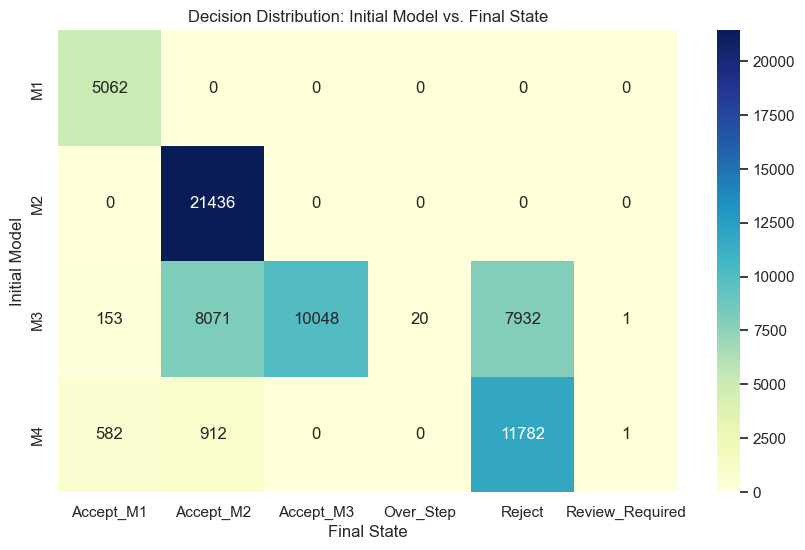

In [32]:
plt.figure(figsize=(10, 6))
decision_matrix = pd.crosstab(df['initial_identified_model'], df['final_state'])
sns.heatmap(decision_matrix, annot=True, cmap="YlGnBu", fmt='d')
plt.title("Decision Distribution: Initial Model vs. Final State")
plt.xlabel("Final State")
plt.ylabel("Initial Model")
plt.show()

初始模型和奖励之间的关系

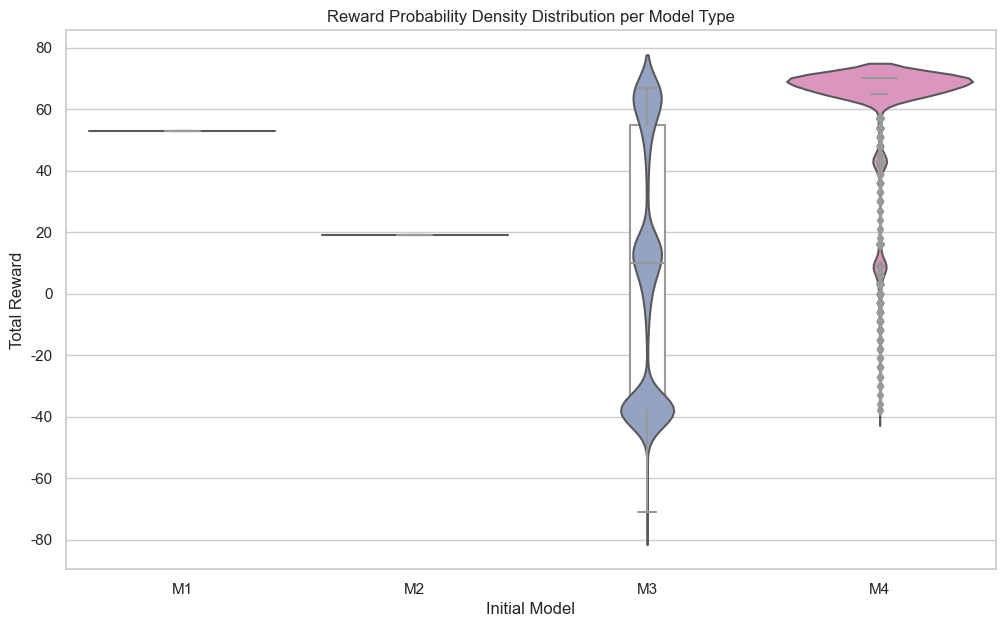

In [33]:
plt.figure(figsize=(12, 7))
sns.violinplot(x='initial_identified_model', y='total_reward', data=df,
               palette="Set2", order=['M1', 'M2', 'M3', 'M4'], inner=None, alpha=0.6)
sns.boxplot(x='initial_identified_model', y='total_reward', data=df,
            width=0.15, color="white", order=['M1', 'M2', 'M3', 'M4'])
plt.title("Reward Probability Density Distribution per Model Type")
plt.xlabel("Initial Model")
plt.ylabel("Total Reward")
plt.show()

对输入输出进行编码

In [34]:
input_features = ['d', 'b', 'r', 'c']
# Encoding inputs for correlation calculation
df_encoded_inputs = df[input_features].copy()
le = LabelEncoder()
for col in input_features:
    df_encoded_inputs[col] = le.fit_transform(df_encoded_inputs[col].astype(str))

# Encoding final_state into actual outcomes
df_decisions = pd.get_dummies(df['final_state'], prefix='Result')

# Combine encoded inputs, numeric metrics, and expanded decisions
analysis_df = pd.concat([df_encoded_inputs, df_decisions, df[['total_steps', 'total_reward']]], axis=1)

输入与终端决策之间的关系

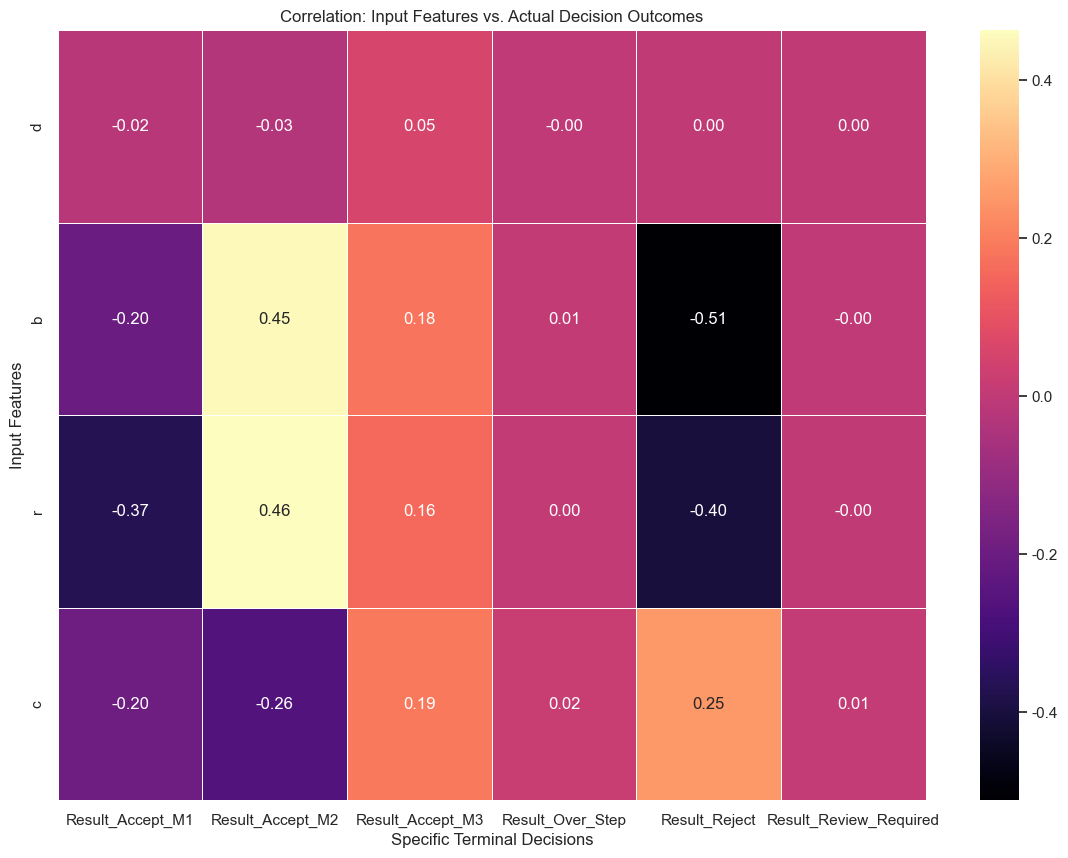

In [35]:
plt.figure(figsize=(14, 10))
# Calculate correlation and slice it to show Features vs. Specific Decisions
corr_matrix = analysis_df.corr()
sub_corr = corr_matrix.loc[input_features, df_decisions.columns]

sns.heatmap(sub_corr, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)
plt.title("Correlation: Input Features vs. Actual Decision Outcomes")
plt.xlabel("Specific Terminal Decisions")
plt.ylabel("Input Features")
plt.show()

奖励与动作步数之间的关系

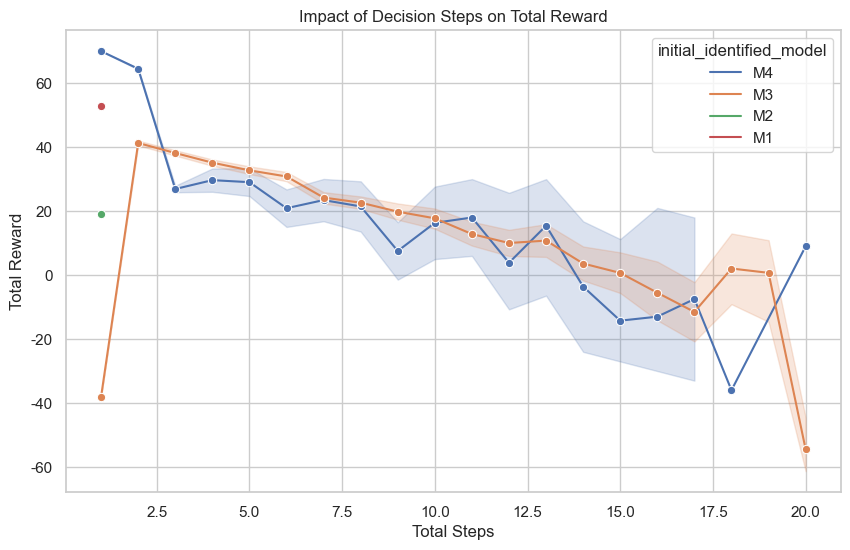

In [36]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='total_steps', y='total_reward', hue='initial_identified_model', data=df, marker='o')
plt.title("Impact of Decision Steps on Total Reward")
plt.xlabel("Total Steps")
plt.ylabel("Total Reward")
plt.show()

那些输入导致Reject

--- d 在 Reject 中的分布 ---
unstructured_text    0.362991
image                0.230598
multimodal           0.189206
structured           0.155220
video                0.061986
Name: d, dtype: float64
--- b 在 Reject 中的分布 ---
categorisation    0.597646
remote_id         0.197778
none              0.106371
verification      0.098204
Name: b, dtype: float64
--- c 在 Reject 中的分布 ---
non_compliant     0.438064
inadequate_SCC    0.222634
EU_only           0.171908
adequacy          0.167394
Name: c, dtype: float64
--- m 在 Reject 中的分布 ---
insufficient    0.784417
suboptimal      0.209039
optimal         0.006544
Name: m, dtype: float64


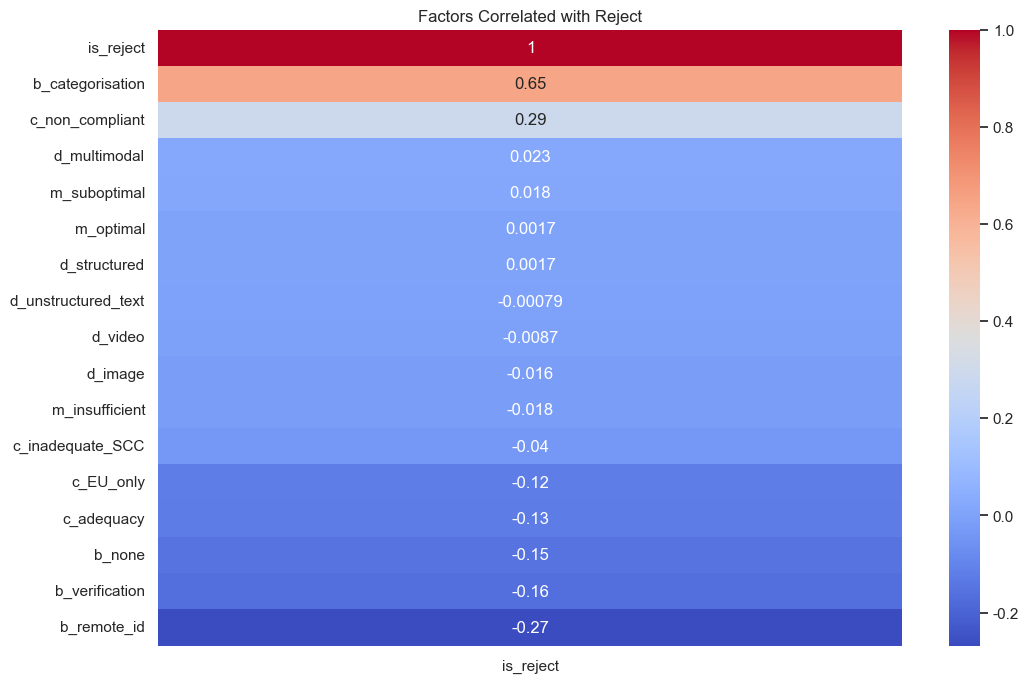

In [37]:
reject_df = df[df['final_state'] == 'Reject']

# 观察类别特征（例如 d, b, c）在 Reject 中的分布
features_to_check = ['d', 'b', 'c', 'm']
for col in features_to_check:
    print(f"--- {col} 在 Reject 中的分布 ---")
    print(reject_df[col].value_counts(normalize=True))

df['is_reject'] = (df['final_state'] == 'Reject').astype(int)
# 对类别变量进行 One-Hot 编码以便计算相关性
df_encoded = pd.get_dummies(df[['d', 'b', 'c', 'm', 'is_reject']])

# 计算相关性并绘图
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr()[['is_reject']].sort_values(by='is_reject', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Factors Correlated with Reject")
plt.show()

在拒绝的动作中，r和d之间的影响

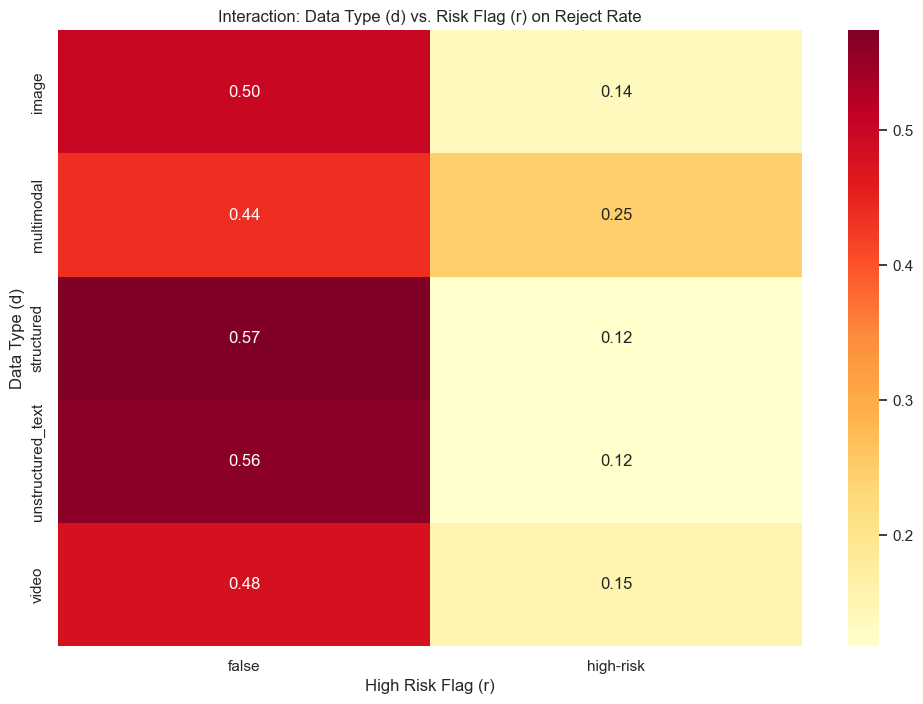

In [38]:
df['is_reject'] = (df['final_state'] == 'Reject').astype(int)
plt.figure(figsize=(12, 8))
interaction_pivot = df.pivot_table(index='d', columns='r', values='is_reject', aggfunc='mean')
sns.heatmap(interaction_pivot, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Interaction: Data Type (d) vs. Risk Flag (r) on Reject Rate")
plt.ylabel("Data Type (d)")
plt.xlabel("High Risk Flag (r)")
plt.show()

In [39]:
metrics_list = df['m_metrics'].apply(ast.literal_eval).tolist()
metrics_df = pd.DataFrame(metrics_list, columns=['m_loss', 'm_accuracy', 'm_recall', 'm_precision'])

# 3. 准备主分析表
# 选择基础特征 + 结果特征
base_features = ['d', 'b', 'r', 'c', 'm']
outcomes = ['total_steps', 'total_reward', 'final_state']
df_analysis = pd.concat([df[base_features], metrics_df, df[outcomes]], axis=1)

# 4. 数值化处理
le = LabelEncoder()
for col in ['d', 'b', 'r', 'c', 'm', 'final_state']:
    df_analysis[col] = le.fit_transform(df_analysis[col].astype(str))

# 5. 计算相关性矩阵
corr_matrix = df_analysis.corr()

if 'final_state' in df.columns:
    df_reject = pd.get_dummies(df['final_state'])['Reject']
    reject_corr = \
    pd.concat([df_analysis.drop(columns=['final_state', 'total_reward', 'total_steps']), df_reject], axis=1).corr()[
        'Reject']

    print("-" * 30)
    print("Metrics correlation with 'Reject' decision:")
    print(reject_corr[['m_loss', 'm_accuracy', 'm_recall', 'm_precision']].sort_values(ascending=False))
    print("-" * 30)

------------------------------
Metrics correlation with 'Reject' decision:
m_precision    0.009283
m_accuracy     0.006846
m_recall       0.002535
m_loss        -0.000505
Name: Reject, dtype: float64
------------------------------


处理数据

In [40]:
input_features = ['d', 'b', 'r', 'c', 'm']
df_inputs = df[input_features].copy()
le = LabelEncoder()
for col in input_features:
    df_inputs[col] = le.fit_transform(df_inputs[col].astype(str))

# 将 final_state 展开为“真正的结果” (One-Hot Encoding)
# 这会生成 Decision_Accept_M1, Decision_Reject 等列
df_decisions = pd.get_dummies(df['final_state'], prefix='Decision')

#  合并所有维度进行相关性计算
# 包含：输入基础特征 + 拆解后的指标 + 具体的决策结果 + 总奖励
df_full_analysis = pd.concat([df_inputs, metrics_df, df_decisions, df['total_reward'], df['total_steps']], axis=1)

# 提取相关性矩阵
corr_matrix = df_full_analysis.corr()

# 输入特征 + 性能指标 VS 具体决策结果 ---
# 我们只截取 [输入特征+指标] 作为纵轴，[决策结果] 作为横轴
plt.figure(figsize=(16, 10))

# 纵轴选择：基础特征 + 4个指标
y_axis_labels = input_features + ['m_loss', 'm_accuracy', 'm_recall', 'm_precision']
# 横轴选择：所有 Decision_ 开头的列
x_axis_labels = [col for col in df_decisions.columns]

# 提取子矩阵
sub_corr_matrix = corr_matrix.loc[y_axis_labels, x_axis_labels]

<Figure size 1600x1000 with 0 Axes>

所有输入与终端决策相关度

Text(47.10937499999999, 0.5, 'Input Features & Model Metrics')

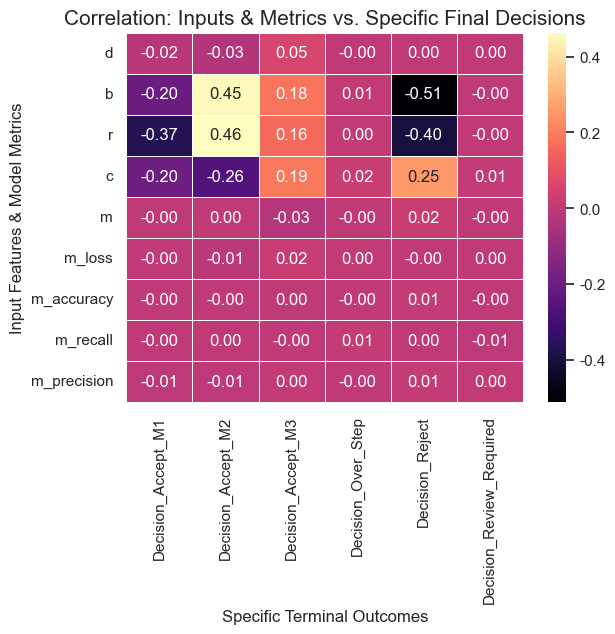

In [41]:
sns.heatmap(sub_corr_matrix, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)
plt.title("Correlation: Inputs & Metrics vs. Specific Final Decisions", fontsize=15)
plt.xlabel("Specific Terminal Outcomes", fontsize=12)
plt.ylabel("Input Features & Model Metrics", fontsize=12)

全部变量相关度

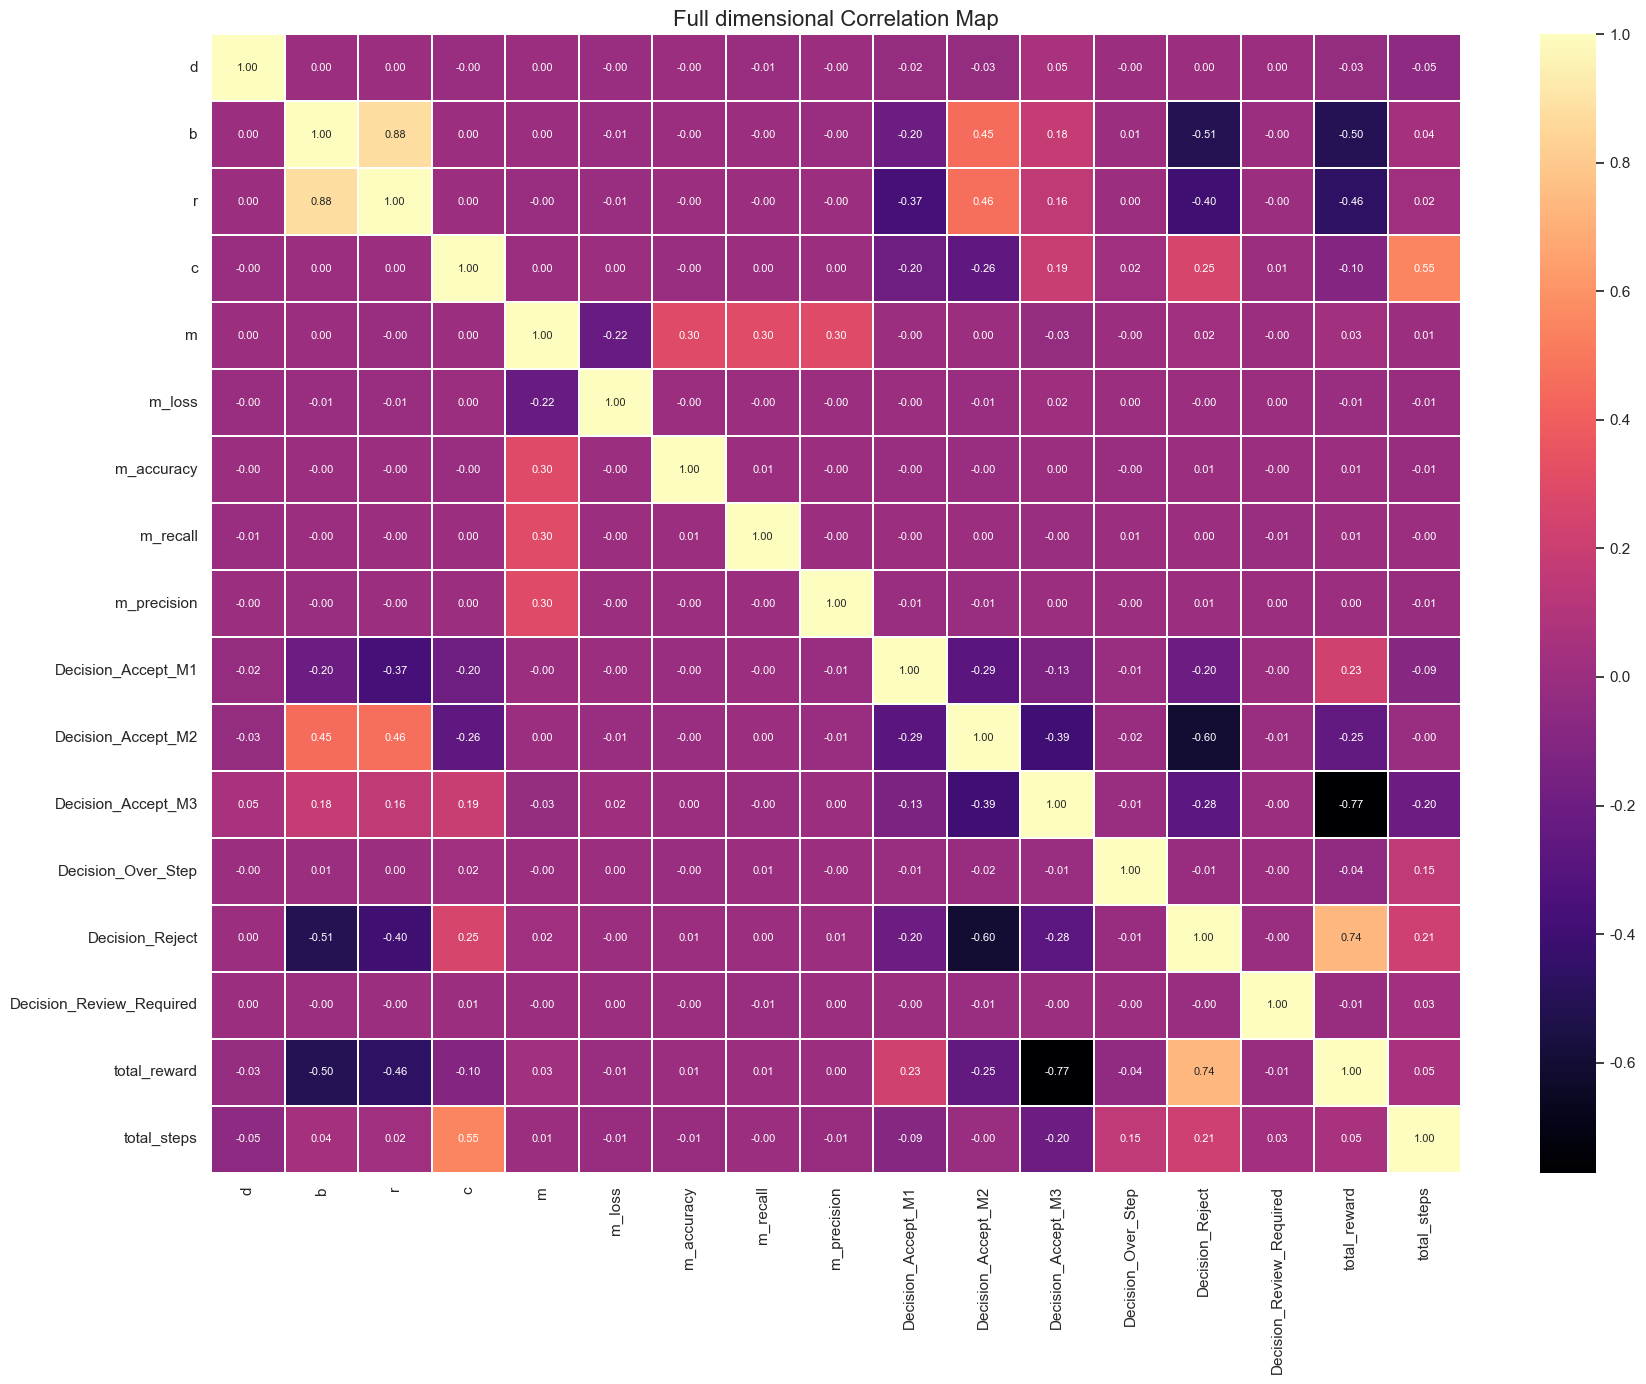

In [42]:
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, cmap="magma", fmt=".2f", linewidths=0.3, annot_kws={"size": 8})
plt.title("Full dimensional Correlation Map", fontsize=16)
plt.tight_layout()
plt.show()


In [43]:
print("-" * 30)
print("Decision Outcome Distribution:")
print(df['final_state'].value_counts())
print("-" * 30)

------------------------------
Decision Outcome Distribution:
Accept_M2          30419
Reject             19714
Accept_M3          10048
Accept_M1           5797
Over_Step             20
Review_Required        2
Name: final_state, dtype: int64
------------------------------


d值与终端决策之间的关系

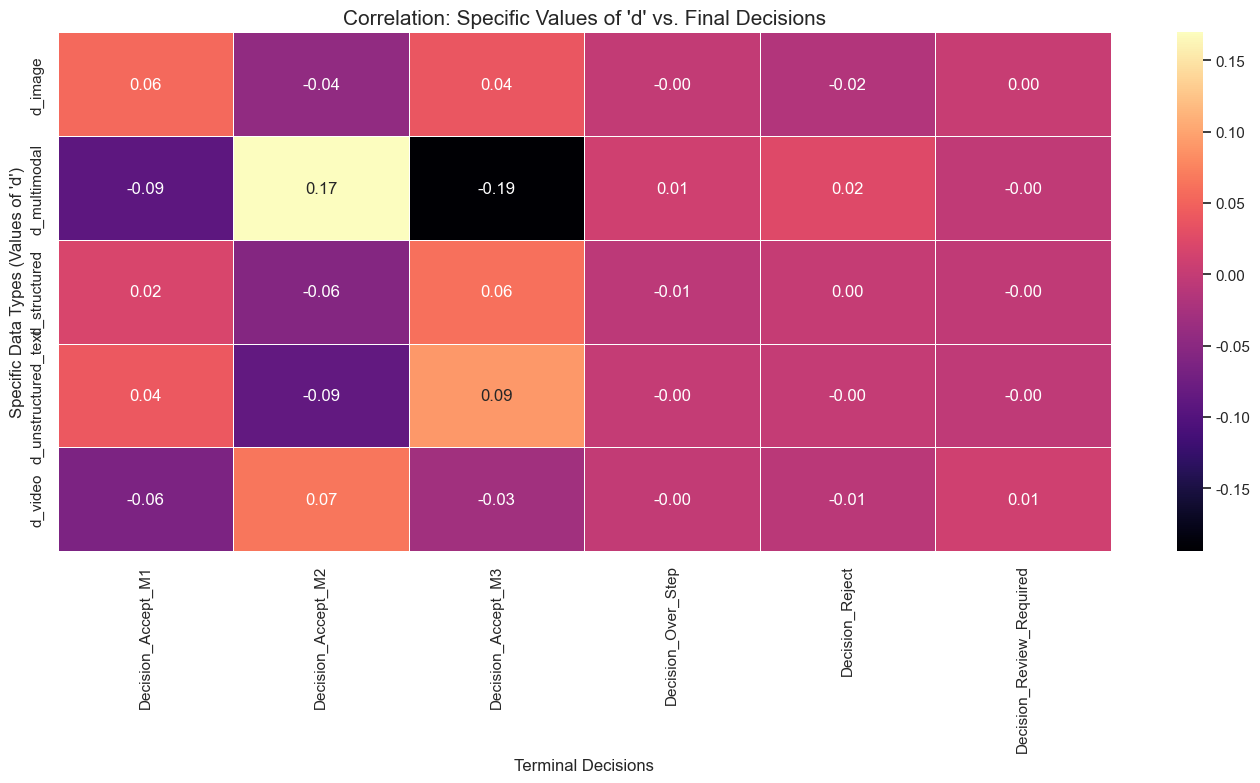

In [44]:
sns.set_theme(style="whitegrid")

#将特征 'd' 展开为具体数值列 (One-Hot)
df_d_values = pd.get_dummies(df['d'], prefix='d')
df_decisions = pd.get_dummies(df['final_state'], prefix='Decision')

# 我们只关注 d 的具体值与最终决策之间的关系
df_d_corr = pd.concat([df_d_values, df_decisions], axis=1)
corr_matrix = df_d_corr.corr()
sub_corr = corr_matrix.loc[df_d_values.columns, df_decisions.columns]


plt.figure(figsize=(14, 8))
sns.heatmap(sub_corr, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)

plt.title("Correlation: Specific Values of 'd' vs. Final Decisions", fontsize=15)
plt.xlabel("Terminal Decisions", fontsize=12)
plt.ylabel("Specific Data Types (Values of 'd')", fontsize=12)
plt.tight_layout()
plt.show()

In [45]:
print("-" * 30)
print("Distribution of Decisions per Data Type (d):")
pivot_table = pd.crosstab(df['d'], df['final_state'], normalize='index') * 100
print(pivot_table.round(2).astype(str) + '%')
print("-" * 30)

------------------------------
Distribution of Decisions per Data Type (d):
final_state       Accept_M1 Accept_M2 Accept_M3 Over_Step  Reject  \
d                                                                   
image                11.56%    42.23%    17.62%     0.03%  28.55%   
multimodal            3.23%    64.41%     0.11%     0.07%  32.18%   
structured           10.01%    39.63%    20.32%      0.0%  30.05%   
unstructured_text    10.32%    40.32%    19.51%     0.03%  29.82%   
video                 2.02%    58.45%    11.12%     0.02%  28.37%   

final_state       Review_Required  
d                                  
image                       0.01%  
multimodal                   0.0%  
structured                   0.0%  
unstructured_text            0.0%  
video                       0.02%  
------------------------------


d值和r值之间的关系 在Reject之间

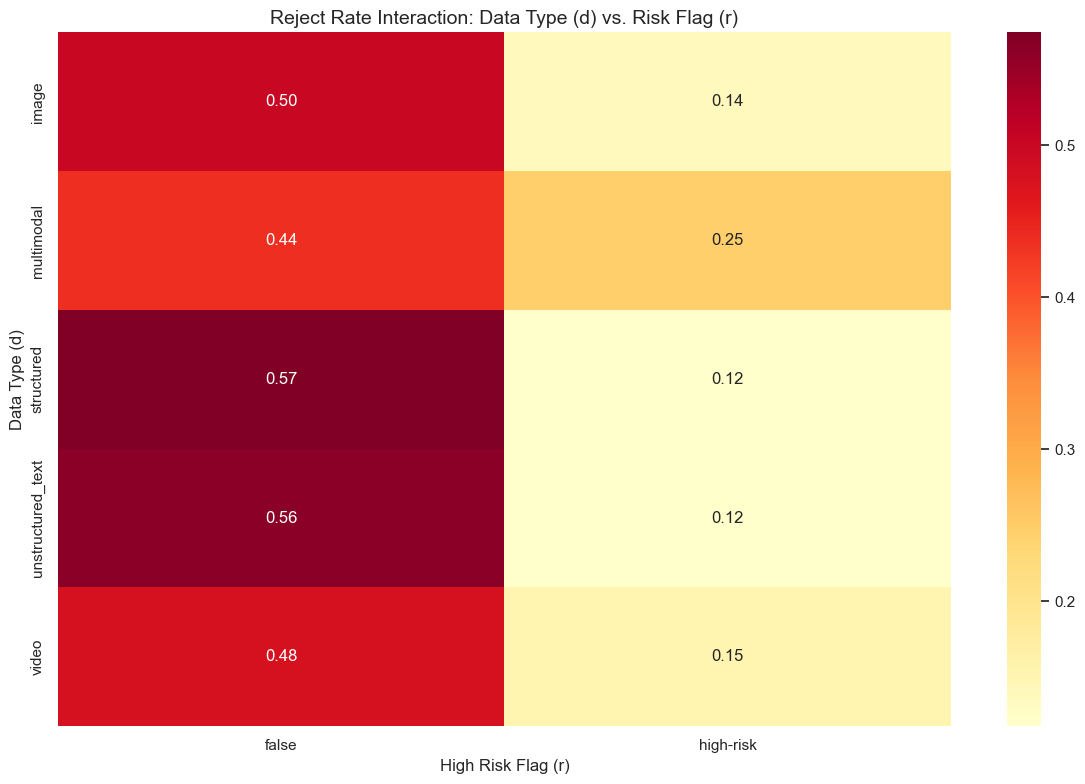

In [46]:
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False
# --- Analysis 1: Multi-Feature Interaction (Reject Rate Matrix) ---
# Observation: Interaction between Data Type (d) and Risk Level (r)
df['final_state'] = df['final_state'].replace({'M1': 'Reject', 'M2': 'Reject', 'M3': 'Reject'})
df['is_reject'] = (df['final_state'] == 'Reject').astype(int)

metrics_list = df['m_metrics'].apply(ast.literal_eval).tolist()
metrics_df = pd.DataFrame(metrics_list, columns=['m_loss', 'm_accuracy', 'm_recall', 'm_precision'])
df = pd.concat([df, metrics_df], axis=1)
plt.figure(figsize=(12, 8))
interaction_pivot = df.pivot_table(index='d', columns='r', values='is_reject', aggfunc='mean')

sns.heatmap(interaction_pivot, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Reject Rate Interaction: Data Type (d) vs. Risk Flag (r)", fontsize=14)
plt.ylabel("Data Type (d)")
plt.xlabel("High Risk Flag (r)")
plt.tight_layout()
plt.show()

b值与终端决策之间的关系

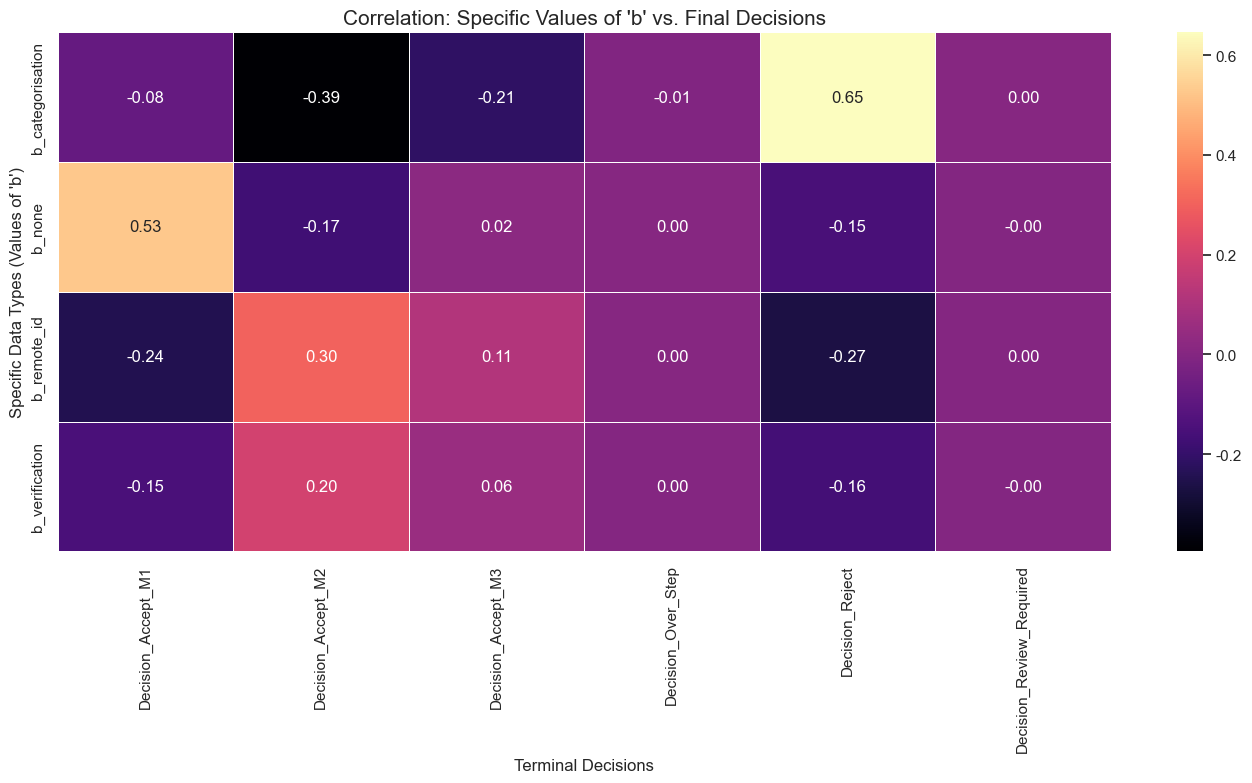

------------------------------
Distribution of Decisions per Data Type (b):
final_state    Accept_M1 Accept_M2 Accept_M3 Over_Step  Reject Review_Required
b                                                                             
categorisation     4.38%     6.87%      0.0%      0.0%  88.74%           0.01%
none              38.53%    29.02%    16.59%     0.05%  15.81%            0.0%
remote_id          0.28%    64.66%    20.21%     0.04%   14.8%            0.0%
verification       0.24%    65.74%    19.23%     0.03%  14.75%            0.0%
------------------------------


In [47]:
sns.set_theme(style="whitegrid")

#将特征 'd' 展开为具体数值列 (One-Hot)
df_d_values = pd.get_dummies(df['b'], prefix='b')
df_decisions = pd.get_dummies(df['final_state'], prefix='Decision')

# 我们只关注 d 的具体值与最终决策之间的关系
df_d_corr = pd.concat([df_d_values, df_decisions], axis=1)
corr_matrix = df_d_corr.corr()
sub_corr = corr_matrix.loc[df_d_values.columns, df_decisions.columns]


plt.figure(figsize=(14, 8))
sns.heatmap(sub_corr, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)

plt.title("Correlation: Specific Values of 'b' vs. Final Decisions", fontsize=15)
plt.xlabel("Terminal Decisions", fontsize=12)
plt.ylabel("Specific Data Types (Values of 'b')", fontsize=12)
plt.tight_layout()
plt.show()
print("-" * 30)
print("Distribution of Decisions per Data Type (b):")
pivot_table = pd.crosstab(df['b'], df['final_state'], normalize='index') * 100
print(pivot_table.round(2).astype(str) + '%')
print("-" * 30)

c值与终端决策之间的关系

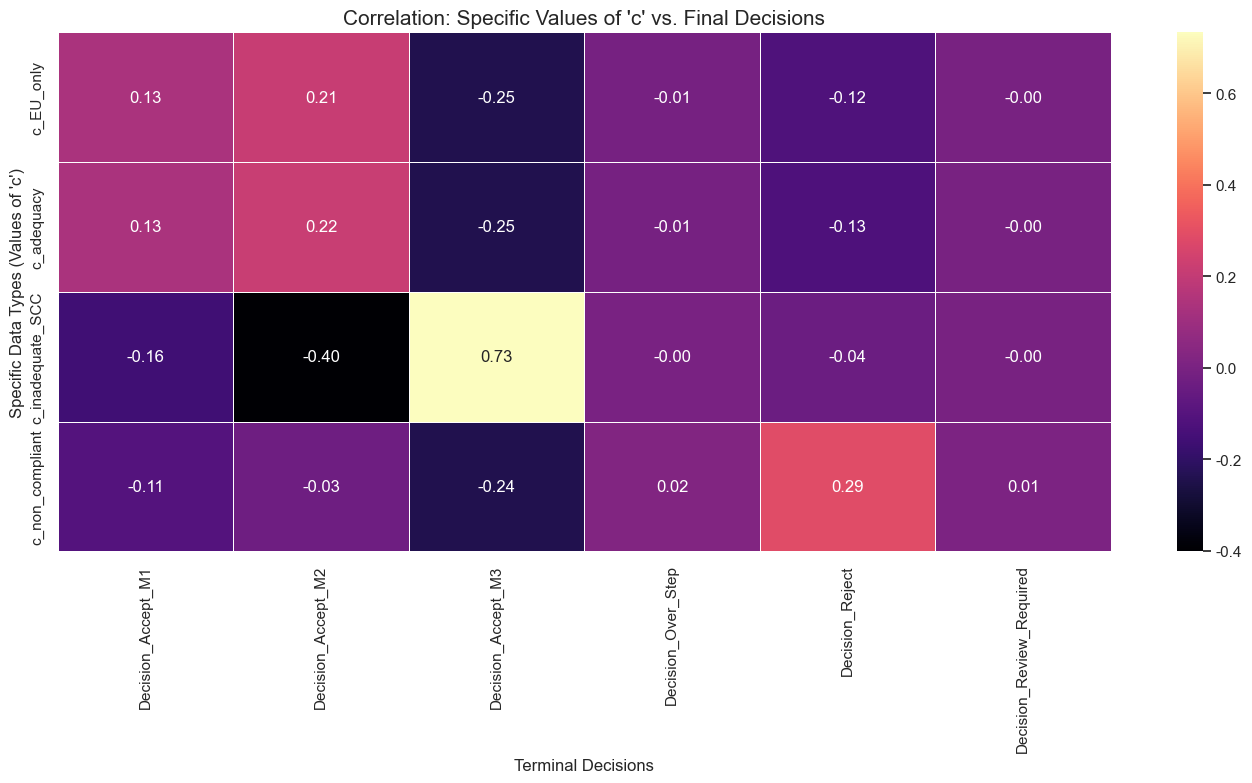

------------------------------
Distribution of Decisions per Data Type (c):
final_state    Accept_M1 Accept_M2 Accept_M3 Over_Step  Reject Review_Required
c                                                                             
EU_only            15.2%    64.42%      0.0%      0.0%  20.38%            0.0%
adequacy           15.3%    64.77%      0.0%      0.0%  19.93%            0.0%
inadequate_SCC     0.95%    11.39%    60.96%     0.02%  26.67%            0.0%
non_compliant      3.54%    43.46%      0.1%      0.1%   52.8%           0.01%
------------------------------


In [48]:
sns.set_theme(style="whitegrid")

#将特征 'd' 展开为具体数值列 (One-Hot)
df_d_values = pd.get_dummies(df['c'], prefix='c')
df_decisions = pd.get_dummies(df['final_state'], prefix='Decision')

# 我们只关注 d 的具体值与最终决策之间的关系
df_d_corr = pd.concat([df_d_values, df_decisions], axis=1)
corr_matrix = df_d_corr.corr()
sub_corr = corr_matrix.loc[df_d_values.columns, df_decisions.columns]


plt.figure(figsize=(14, 8))
sns.heatmap(sub_corr, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)

plt.title("Correlation: Specific Values of 'c' vs. Final Decisions", fontsize=15)
plt.xlabel("Terminal Decisions", fontsize=12)
plt.ylabel("Specific Data Types (Values of 'c')", fontsize=12)
plt.tight_layout()
plt.show()
print("-" * 30)
print("Distribution of Decisions per Data Type (c):")
pivot_table = pd.crosstab(df['c'], df['final_state'], normalize='index') * 100
print(pivot_table.round(2).astype(str) + '%')
print("-" * 30)

执行步数和最终决策以及初始模型的关系

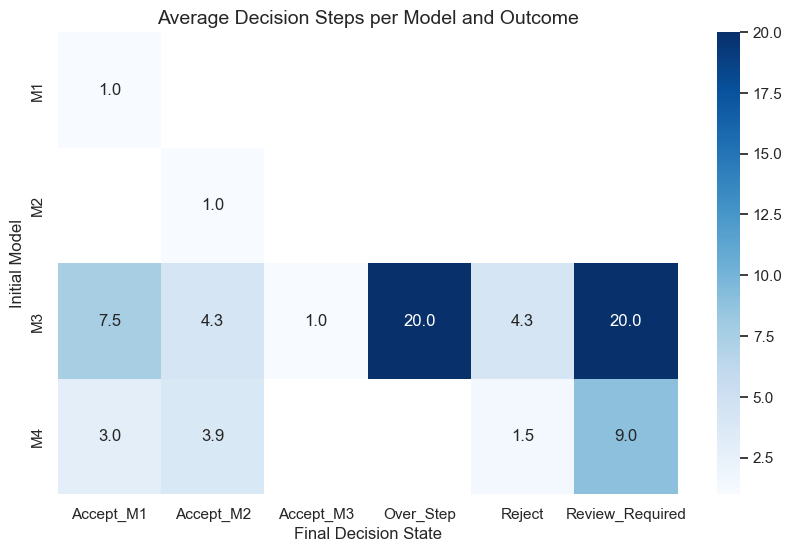

In [49]:
plt.figure(figsize=(10, 6))
step_summary = df.groupby(['initial_identified_model', 'final_state'])['total_steps'].mean().unstack()
sns.heatmap(step_summary, annot=True, cmap="Blues", fmt=".1f")
plt.title("Average Decision Steps per Model and Outcome", fontsize=14)
plt.xlabel("Final Decision State")
plt.ylabel("Initial Model")
plt.show()

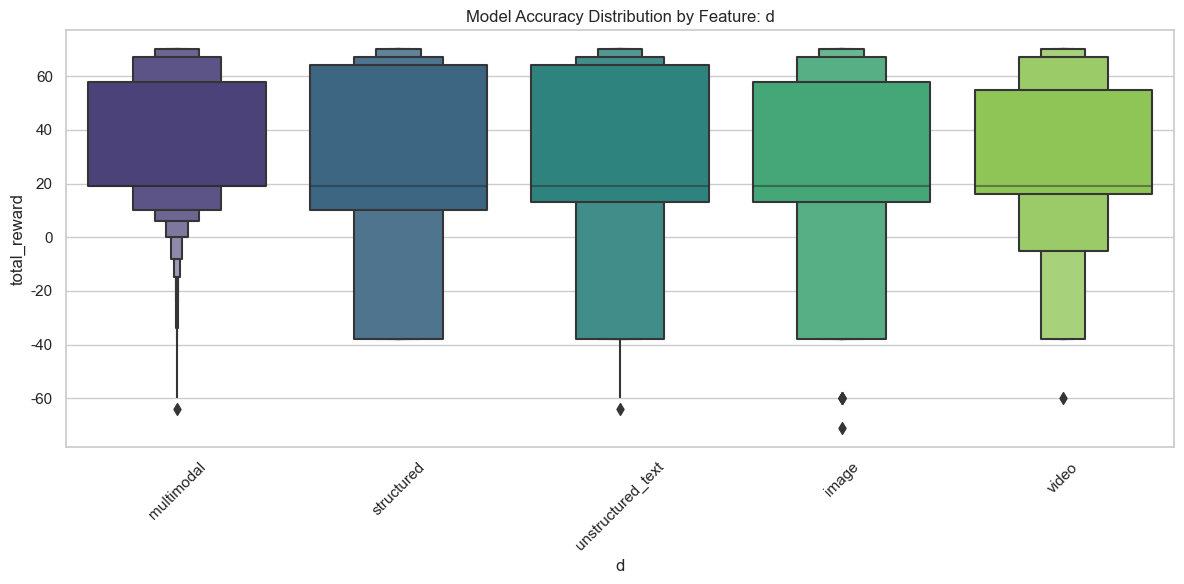

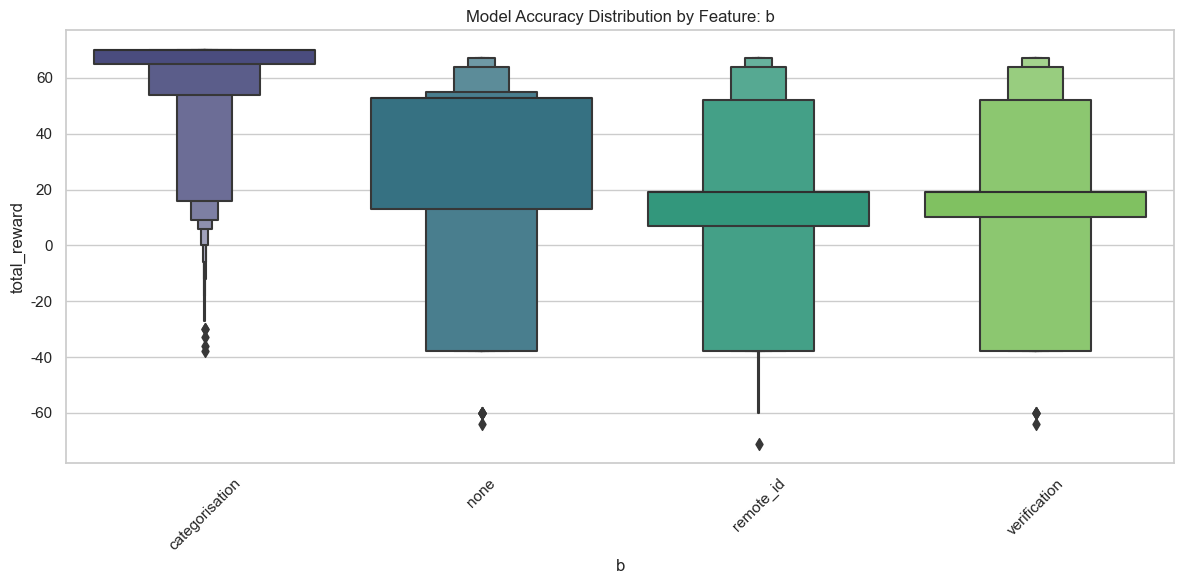

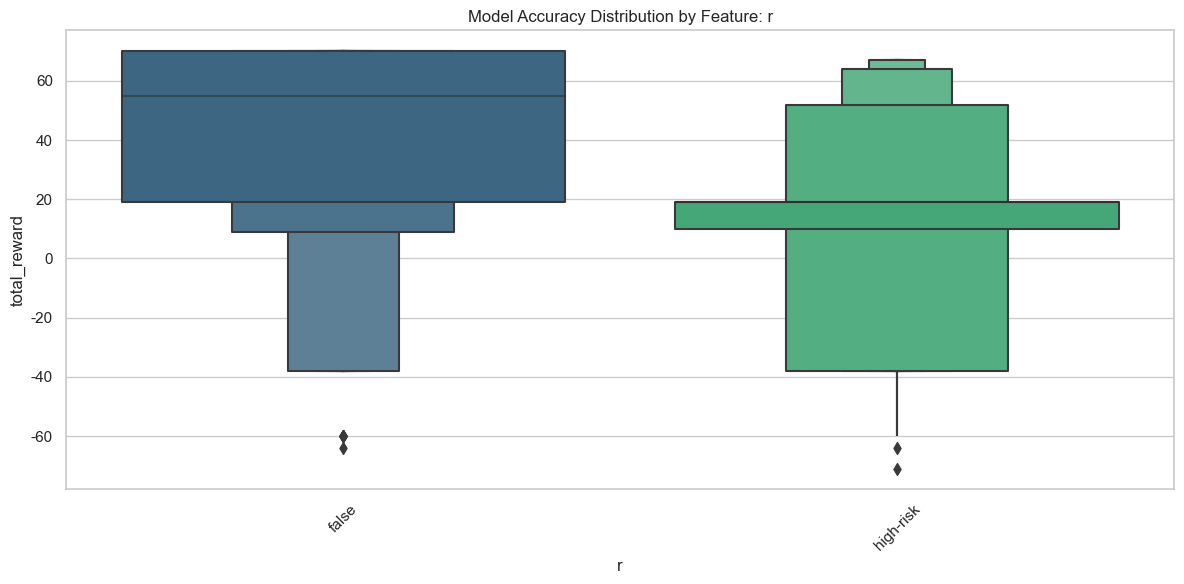

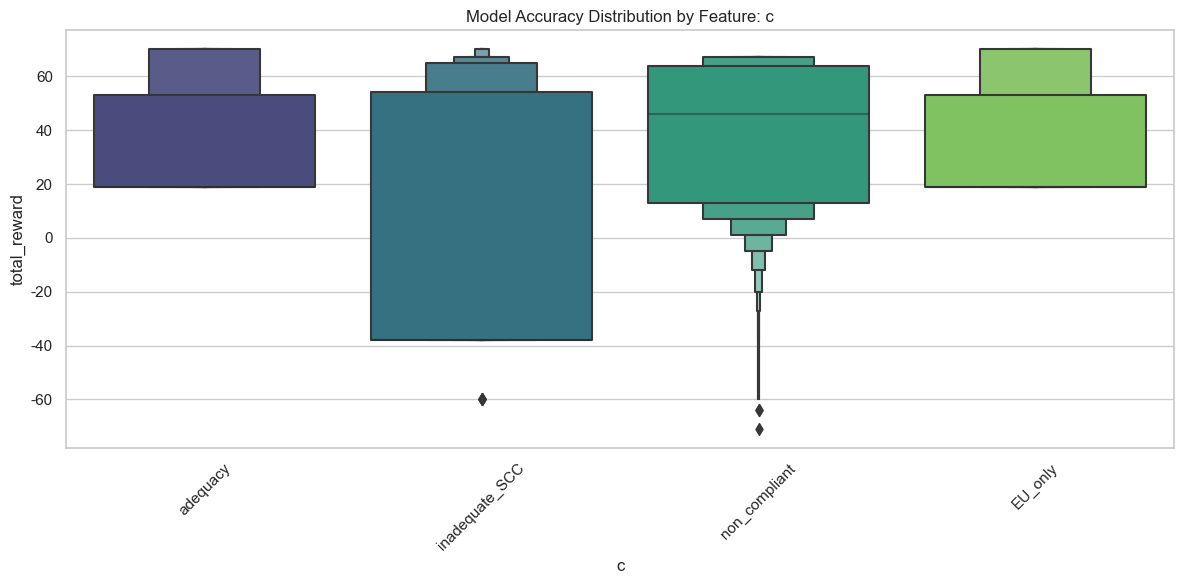

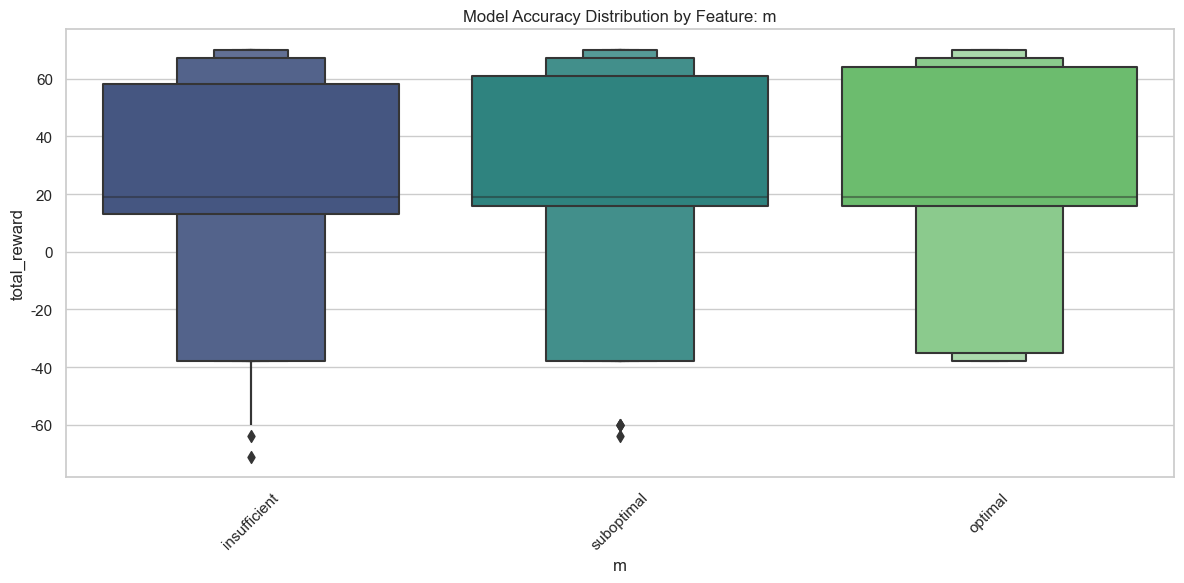

In [50]:
def plot_accuracy_analysis(df, features, label):
    """
    深度分析：针对每一个输入变量，分析其对 m_accuracy 的影响分布
    """
    for col in features:
        plt.figure(figsize=(12, 6))
        # 使用 Boxenplot 适合展示大规模数据的分布，比 Boxplot 更细致
        sns.boxenplot(x=col, y=label, data=df, palette="viridis")
        plt.title(f"Model Accuracy Distribution by Feature: {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
label='total_reward'
plot_accuracy_analysis(df, input_features, label)

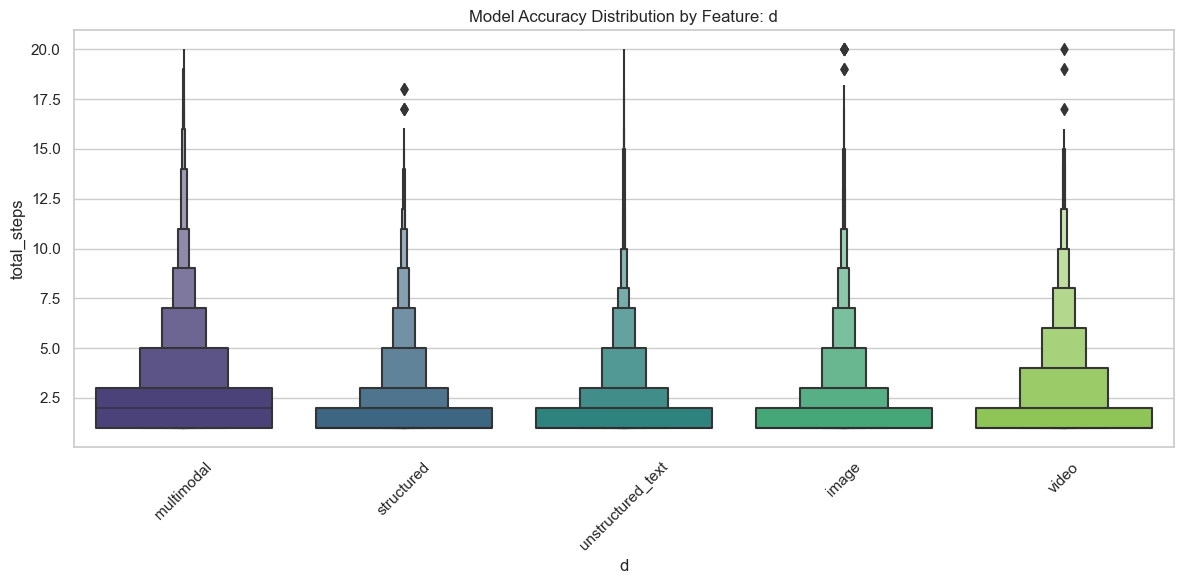

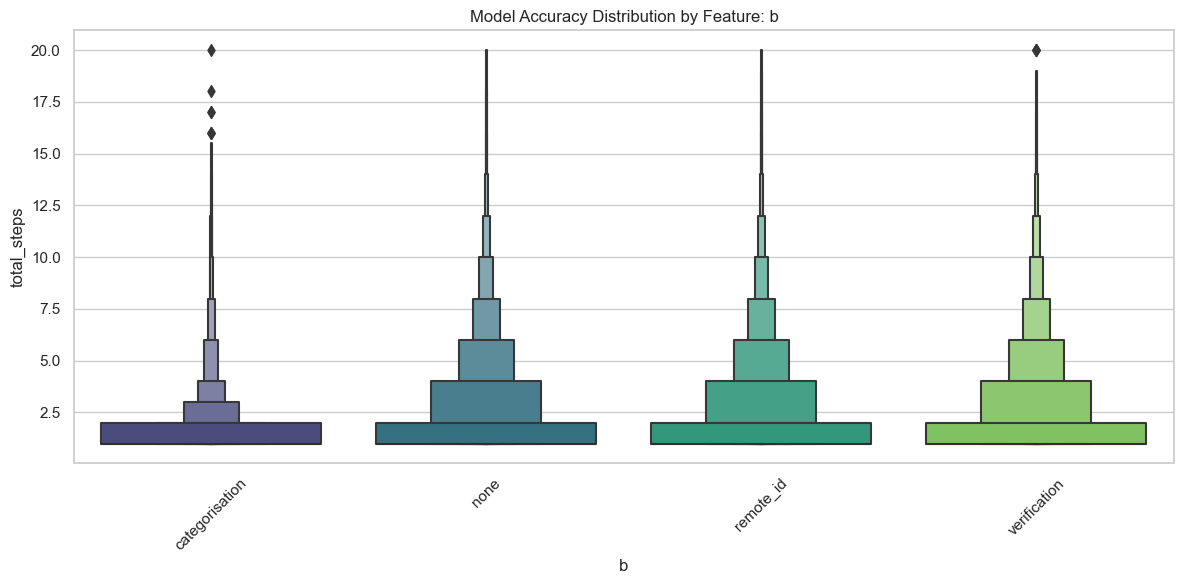

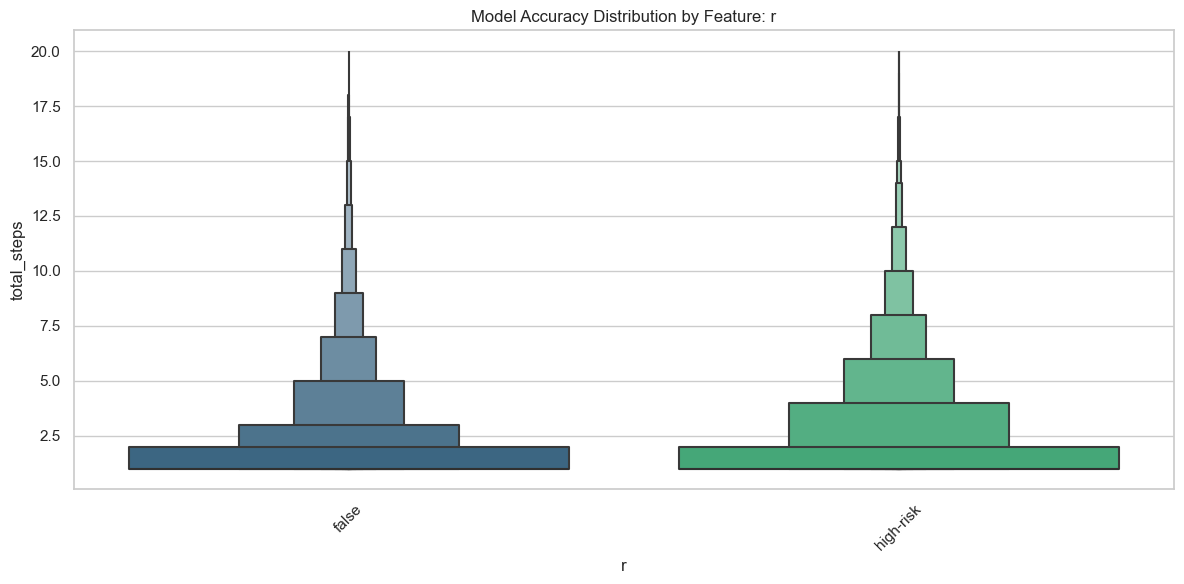

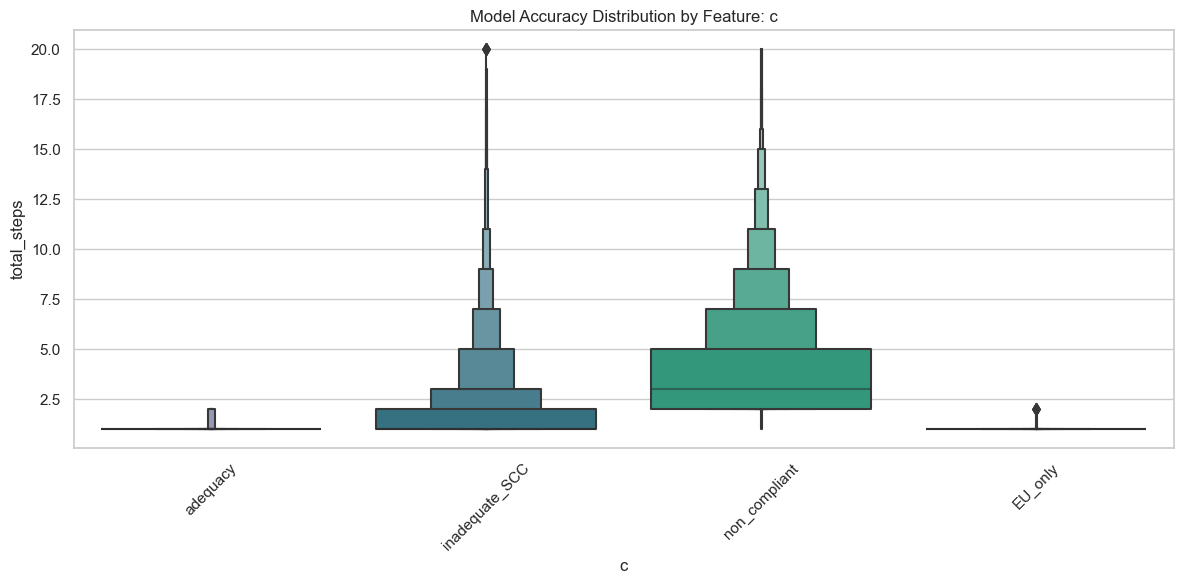

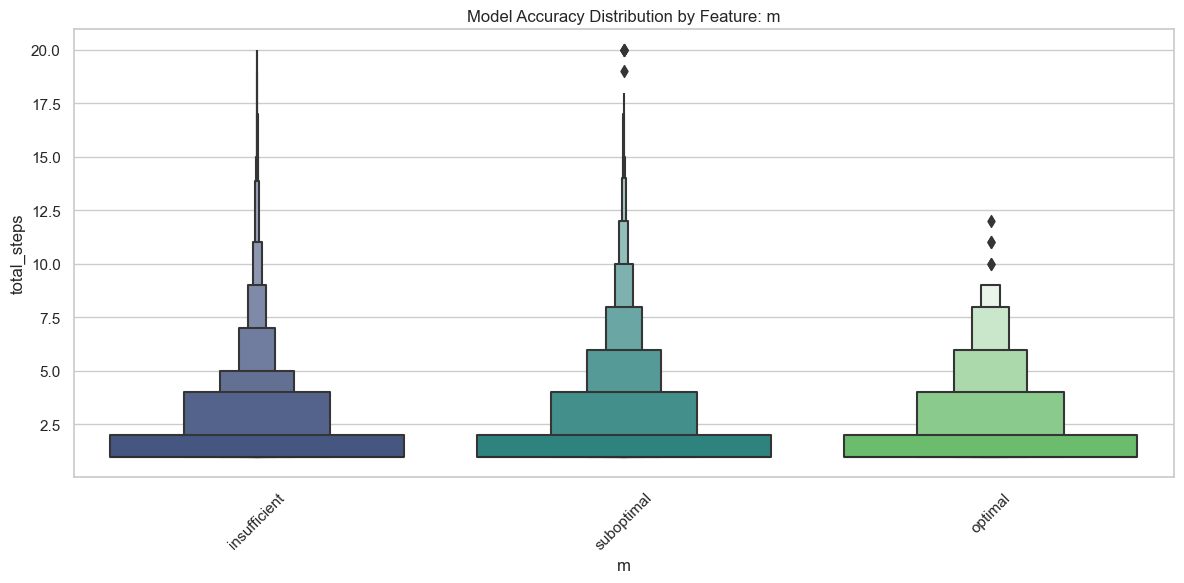

In [51]:
label='total_steps'
plot_accuracy_analysis(df, input_features, label)

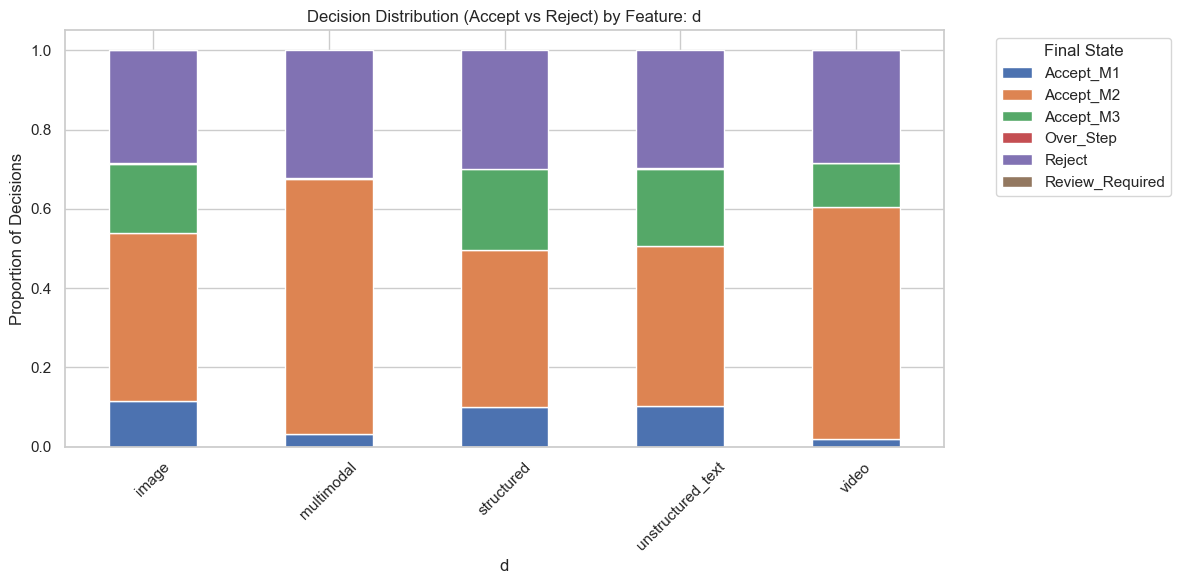

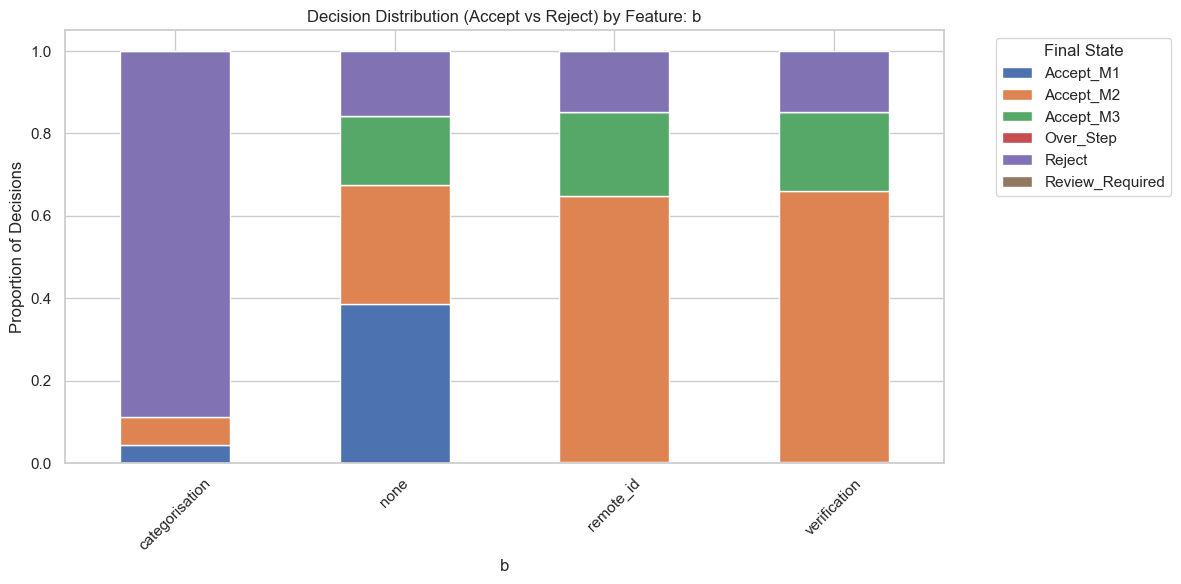

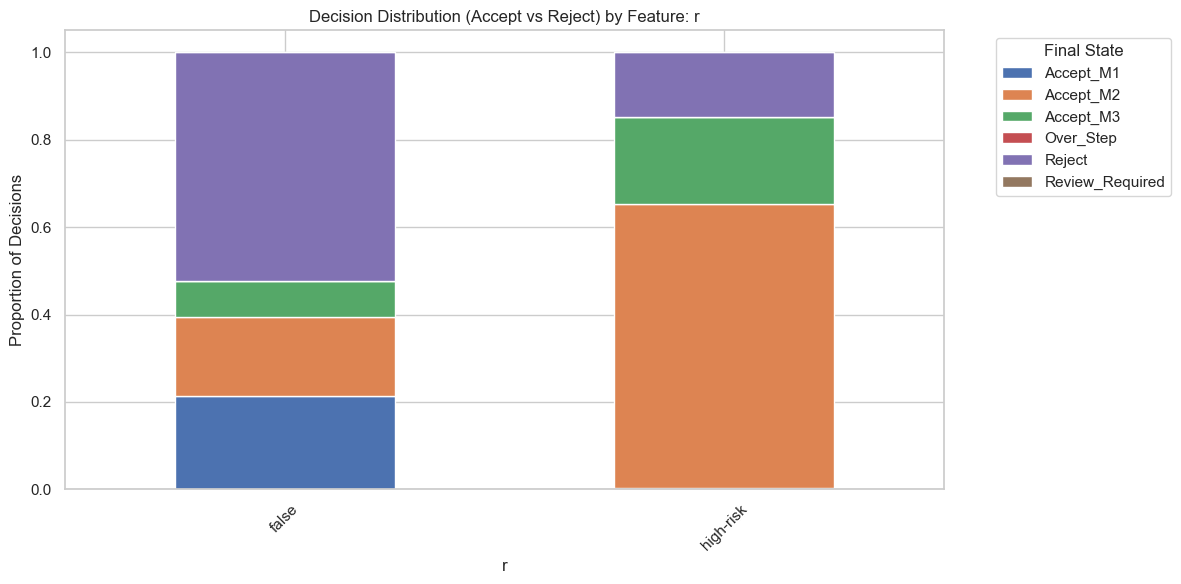

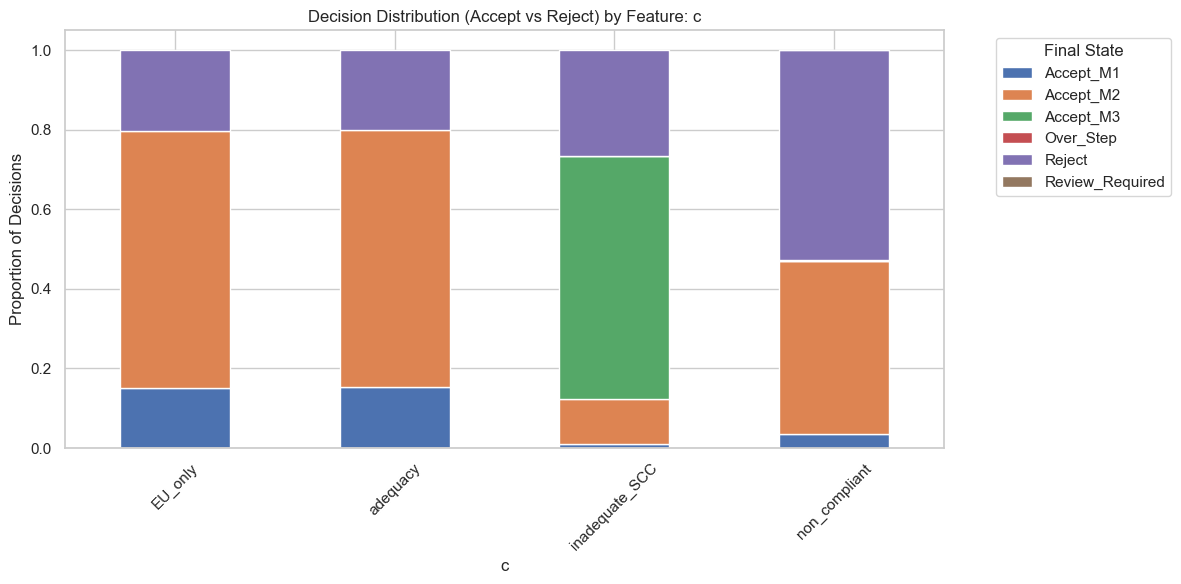

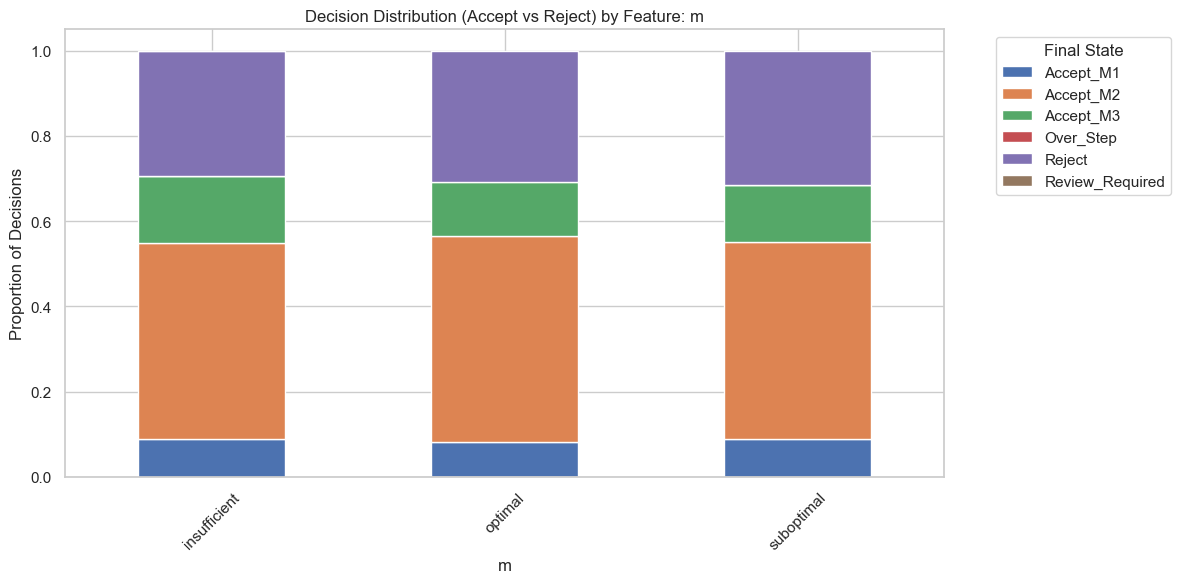

In [52]:
def plot_state_distribution_analysis(df, features, target_col='final_state'):
    """
    修改后：分析不同输入特征对最终决策（Final State）分布的影响
    """
    for col in features:
        plt.figure(figsize=(12, 6))

        # 1. 计算交叉表：特征 vs 状态
        cross_tab = pd.crosstab(df[col], df[target_col])

        # 2. 转换为百分比，以便对比分布比例
        cross_tab_prop = cross_tab.div(cross_tab.sum(1), axis=0)

        # 3. 绘制堆叠柱状图
        cross_tab_prop.plot(kind='bar', stacked=True, ax=plt.gca())

        plt.title(f"Decision Distribution (Accept vs Reject) by Feature: {col}")
        plt.ylabel("Proportion of Decisions")
        plt.xlabel(col)
        plt.legend(title="Final State", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# 调用函数
plot_state_distribution_analysis(df, input_features)

决策树分析

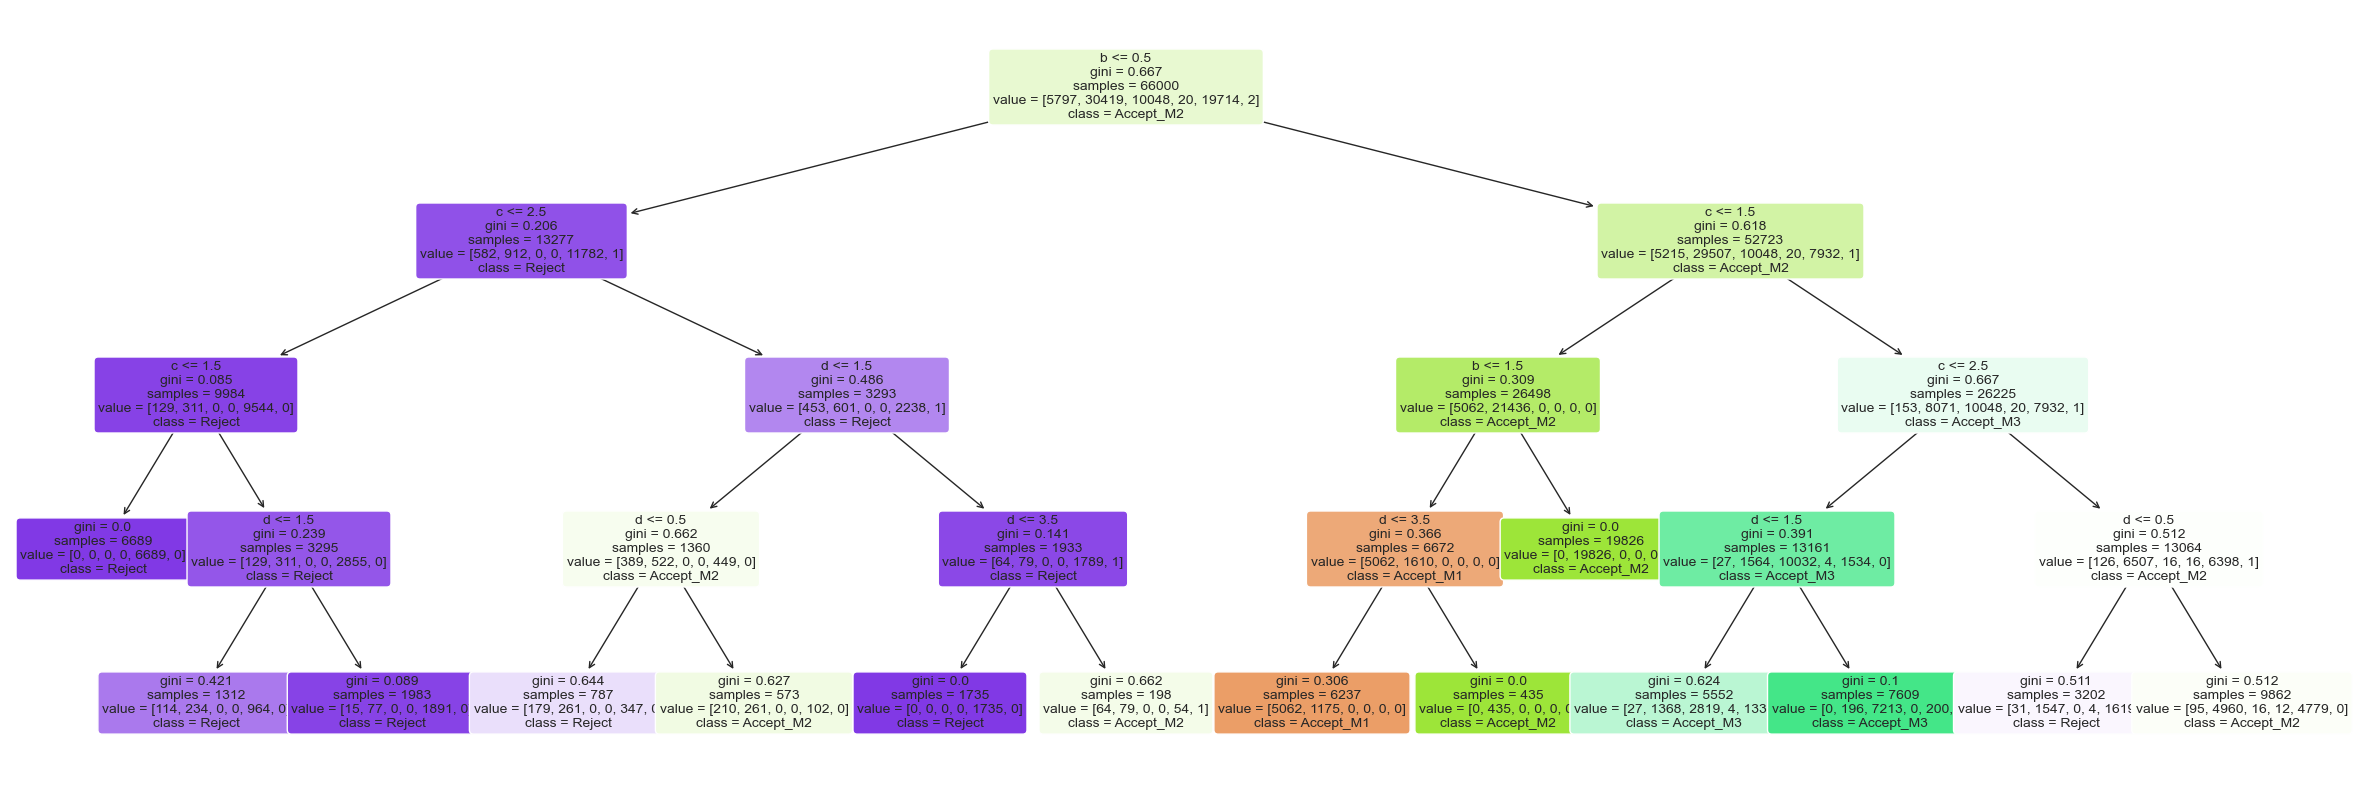

In [53]:
from matplotlib.colors import LinearSegmentedColormap
cmap_colors = ['#FAA26F', '#FEE199', '#B0D6A9']
custom_cmap = LinearSegmentedColormap.from_list("custom_rl", cmap_colors)
le_dict = {}
df_encoded = df_inputs.copy()
for col in input_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    le_dict[col] = le

# 2. 准备目标变量 (final_state)
le_y = LabelEncoder()
y = le_y.fit_transform(df['final_state'])

# 3. 训练决策树
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10)
dt.fit(df_encoded, y)

# 4. 可视化决策树
# plt.figure(figsize=(30, 10))
# # 1. 绘图并获取返回的 artist 对象
# artists = plot_tree(dt, feature_names=input_features,
#                     class_names=le_y.classes_,
#                     filled=True, rounded=True, fontsize=10)
#
# # 2. 自定义颜色填充逻辑
# # 我们将两类结局分配给色板的两端：
# # Accept -> 冷色调 (my_palette[0])
# # Reject -> 暖色调 (my_palette[-1])
#
# for artist in artists:
#     # 获取节点的文本内容来判断它属于哪一类
#     node_text = artist.get_text()
#
#     # 根据类别关键字修改颜色 (请确保 class_names 正确)
#     if "class = Accept" in node_text:
#         artist.set_bbox(dict(facecolor='#7BC0CD', edgecolor='black', boxstyle='round,pad=0.3'))
#     elif "class = Reject" in node_text:
#         artist.set_bbox(dict(facecolor='#ED8D5A', edgecolor='black', boxstyle='round,pad=0.3'))
#     else:
#         # 中间决策节点使用中性色
#         artist.set_bbox(dict(facecolor='#DBCB92', edgecolor='grey', boxstyle='round,pad=0.3'))
#
# plt.title("Decision Tree: Customized Color Scheme (Input Features vs Final State)", fontsize=15)
# plt.show()
plt.figure(figsize=(30, 10))
# plot_tree 本身不支持直接传 cmap，但我们可以修改生成的 patch
viz = plot_tree(dt, feature_names=input_features, class_names=le_y.classes_,
                filled=True, rounded=True, fontsize=10)

for artist in viz:
    # 获取节点的 Gini 指数或 Value 来决定颜色深浅
    # 这里通过 artist 关联的矩形框修改颜色
    if isinstance(artist, plt.Text):
        # 这里的逻辑可以根据你的具体类别索引进一步微调
        pass

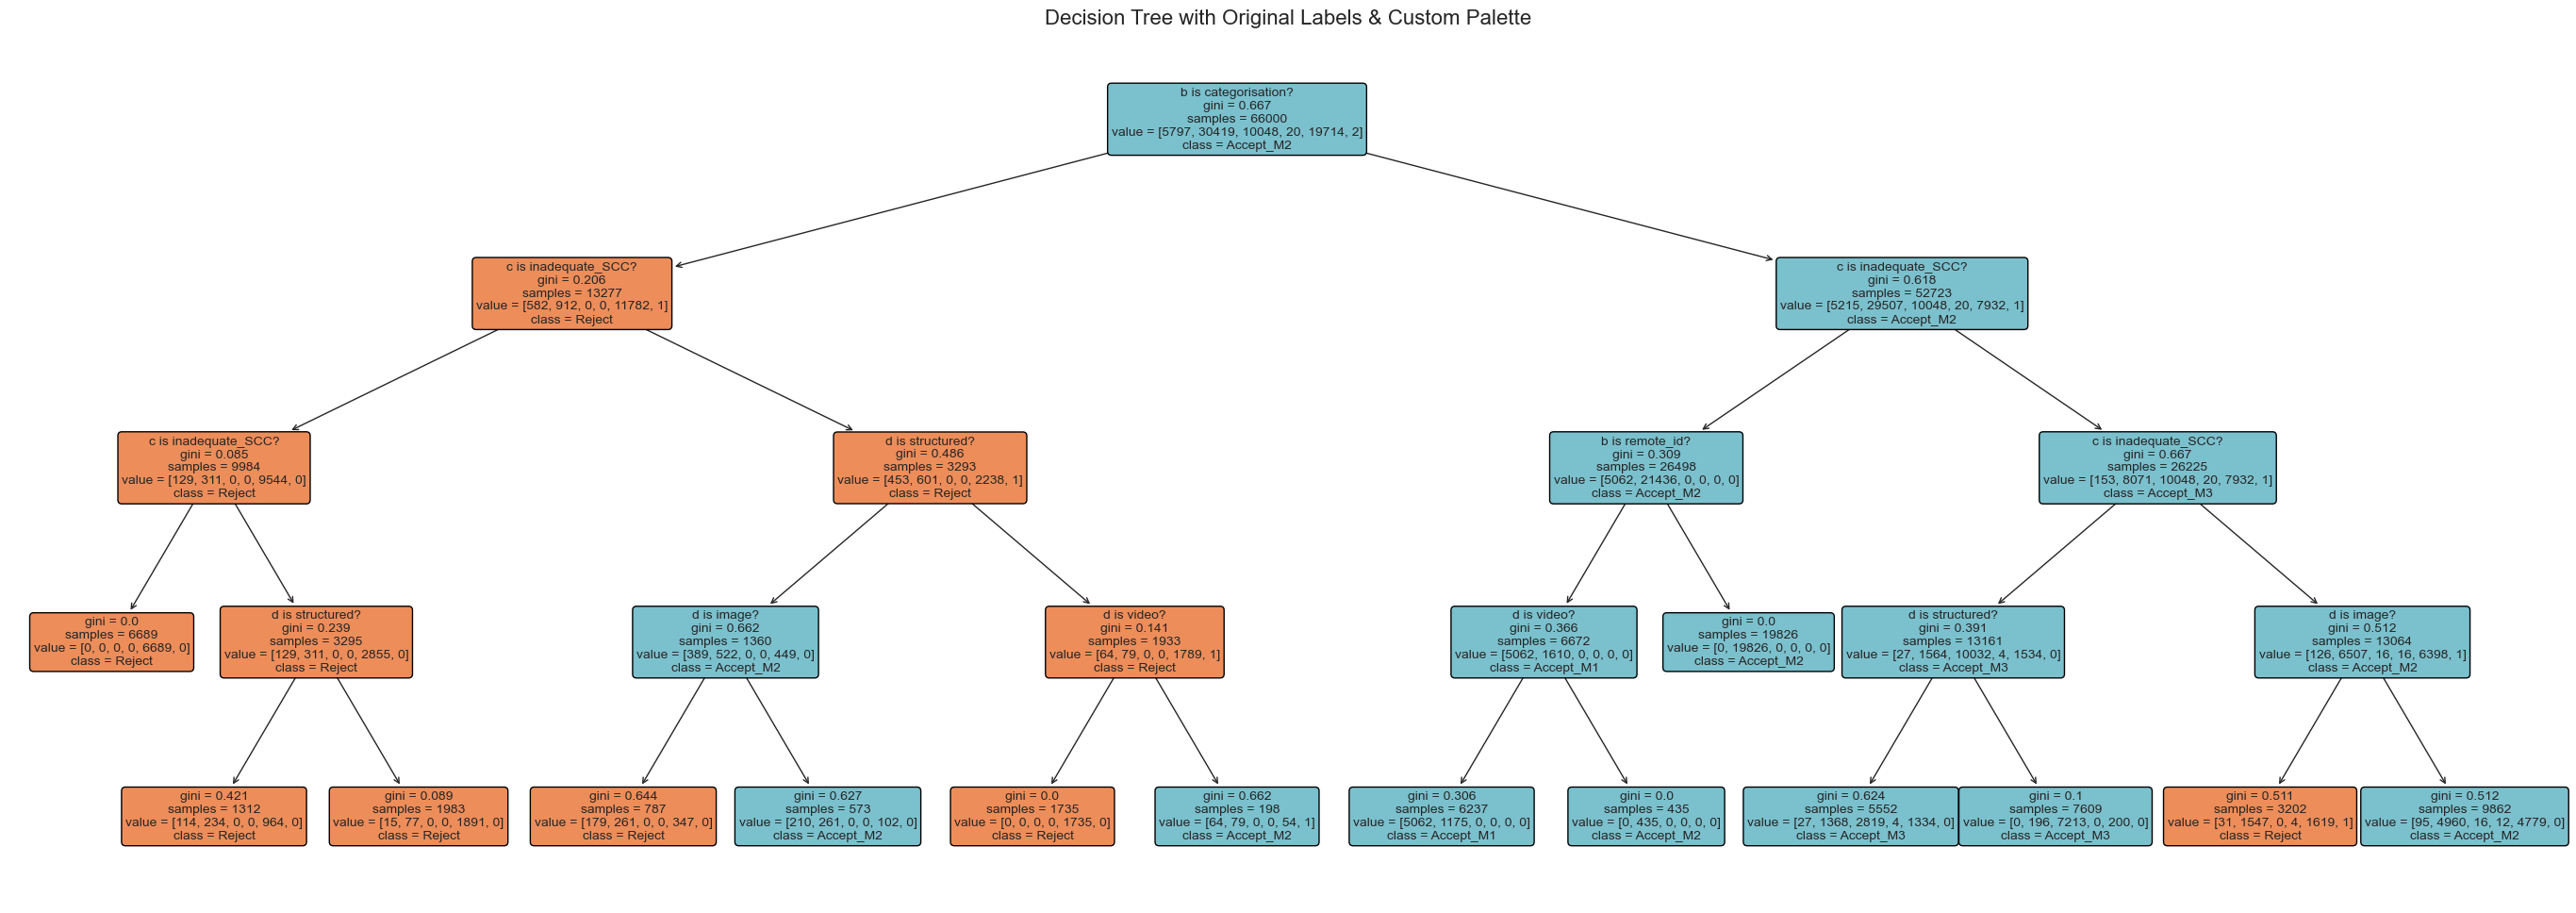

In [54]:
import re
plt.figure(figsize=(35, 12))
# 1. 正常绘图并获取返回的 artists
artists = plot_tree(dt, feature_names=input_features,
                    class_names=le_y.classes_,
                    filled=True, rounded=True, fontsize=10)

# 2. 遍历每个节点，替换编码值为原始标签
for artist in artists:
    text = artist.get_text()

    # 使用正则表达式匹配类似 "d <= 0.5" 或 "c <= 1.5" 的模式
    for col in input_features:
        pattern = rf"{col} <= ([\d\.]+)"
        match = re.search(pattern, text)

        if match:
            threshold = float(match.group(1))
            # 找到最接近该阈值的原始标签
            # 因为 LabelEncoder 是按字母排序分配 0, 1, 2...
            # <= 0.5 通常意味着索引为 0 的那个类别
            original_labels = le_dict[col].classes_
            idx = int(round(threshold))

            # 这里的逻辑：<= 0.5 指的是判断是否为第一个类别
            if idx < len(original_labels):
                label_val = original_labels[idx]
                new_text = text.replace(f"{col} <= {match.group(1)}", f"{col} is {label_val}?")
                artist.set_text(new_text)

    if "class = Accept" in text:
        artist.set_bbox(dict(facecolor='#7BC0CD', edgecolor='black', boxstyle='round,pad=0.3'))
    elif "class = Reject" in text:
        artist.set_bbox(dict(facecolor='#ED8D5A', edgecolor='black', boxstyle='round,pad=0.3'))
    else:
        artist.set_bbox(dict(facecolor='#DBCB92', edgecolor='grey', boxstyle='round,pad=0.3'))

plt.title("Decision Tree with Original Labels & Custom Palette", fontsize=16)
plt.show()

决策路径分析

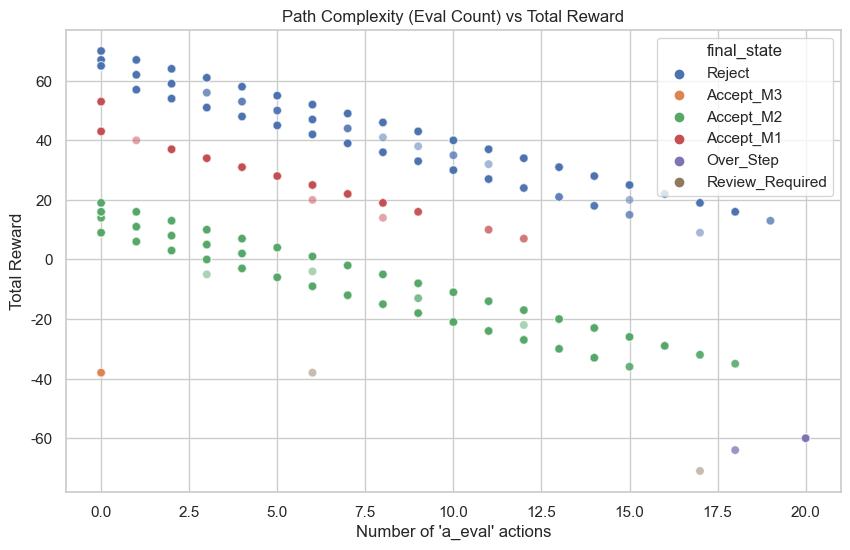

Decision Path Statistics by Final State:
                 total_steps            total_reward
                       mean median max         mean
final_state                                        
Accept_M1          1.373642    1.0  15    51.371226
Accept_M2          1.962228    1.0  19    15.973799
Accept_M3          1.000000    1.0   1   -38.000000
Over_Step         20.000000   20.0  20   -60.400000
Reject             2.632038    2.0  20    64.698996
Review_Required   14.500000   14.5  20   -54.500000


In [55]:
# 1. 提取路径复杂度：计算 a_eval 的次数
df['eval_count'] = df['actions_sequence'].str.count('a_eval')

# 2. 分析路径长度与奖励的关系
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='eval_count', y='total_reward', hue='final_state', alpha=0.5)
plt.title("Path Complexity (Eval Count) vs Total Reward")
plt.xlabel("Number of 'a_eval' actions")
plt.ylabel("Total Reward")
plt.show()

# 3. 统计不同结局的平均步数
path_stats = df.groupby('final_state').agg({
    'total_steps': ['mean', 'median', 'max'],
    'total_reward': 'mean'
})
print("Decision Path Statistics by Final State:\n", path_stats)

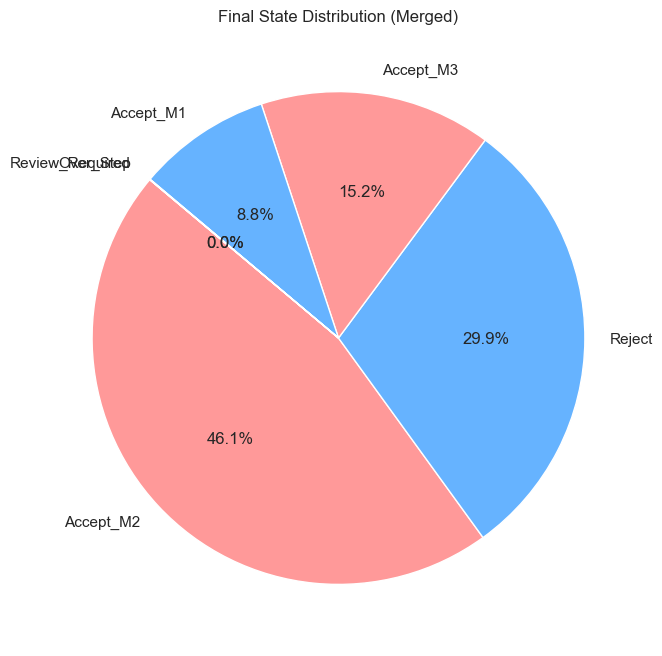

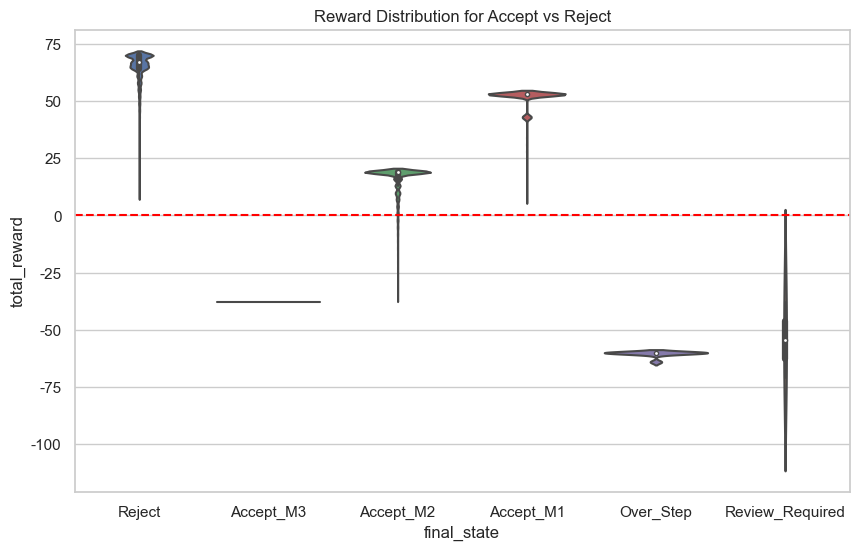

In [56]:
# 状态占比饼图
state_counts = df['final_state'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(state_counts, labels=state_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title("Final State Distribution (Merged)")
plt.show()

# 奖励密度分析 (Violin Plot)
plt.figure(figsize=(10, 6))
sns.violinplot(x='final_state', y='total_reward', data=df)
plt.title("Reward Distribution for Accept vs Reject")
plt.axhline(0, color='red', linestyle='--') # 检查有多少决策是在 0 分以下的
plt.show()

判断a_eval动作是否有用

In [57]:
df_radar_base = df[base_features].copy()
label_mappings = {}

for col in base_features:
    le = LabelEncoder()
    df_radar_base[col] = le.fit_transform(df_radar_base[col].astype(str))
    label_mappings[col] = le.classes_ # 保存映射关系以便后续分析

# 2. 转换 m_loss：Loss 越小越好，在雷达图中需要反转（1 - normalized_loss）
# 假设 metrics_df 已经按你提供的方式定义好了
m_scaler = MinMaxScaler()
metrics_scaled = pd.DataFrame(m_scaler.fit_transform(metrics_df), columns=metrics_df.columns)
metrics_scaled['m_loss'] = 1 - metrics_scaled['m_loss'] # 反转 Loss

# 3. 合并所有维度 (d, b, r, c, m + 4个指标)
radar_all_features = pd.concat([
    pd.DataFrame(m_scaler.fit_transform(df_radar_base), columns=base_features),
    metrics_scaled
], axis=1)
radar_all_features['final_state'] = df['final_state'].values

# 4. 按状态聚合均值
radar_plot_data = radar_all_features.groupby('final_state').mean().reset_index()

In [58]:
def plot_unified_radar(data, feature_cols):
    categories = feature_cols
    num_vars = len(categories)

    # 计算角度
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] # 闭合圆圈

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    for i, row in data.iterrows():
        values = row[categories].values.flatten().tolist()
        values += values[:1] # 闭合

        state_label = row['final_state']
        ax.plot(angles, values, linewidth=2, label=state_label)
        ax.fill(angles, values, alpha=0.15)

    # 极坐标美化
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), categories)
    ax.set_ylim(0, 1)

    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title("Full Feature Universe: Inputs & Metrics Fingerprint", size=16, pad=30)
    plt.show()

# 定义要展示的特征全集
all_display_cols = base_features + ['m_loss', 'm_accuracy', 'm_recall', 'm_precision']
plot_unified_radar(radar_plot_data, all_display_cols)

NameError: name 'np' is not defined

In [ ]:
import numpy as np
metrics_names = ['m_loss', 'm_accuracy', 'm_recall', 'm_precision']
df_radar = pd.concat([metrics_df, df['final_state'].reset_index(drop=True)], axis=1)
radar_data = df_radar.groupby('final_state').mean().reset_index()

# 2. 绘图参数设置
categories = metrics_names
num_vars = len(categories)

# 计算角度（将圆周分为4份）
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # 闭合圆周

# 设置画布
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, row in radar_data.iterrows():
    state_label = row['final_state']
    values = row[categories].values.flatten().tolist()
    values += values[:1]  # 闭合数值环路

    # 绘制线条
    ax.plot(angles, values, linewidth=2, label=state_label)
    # 填充颜色
    ax.fill(angles, values, alpha=0.2)

# 4. 优化坐标轴和标签
ax.set_theta_offset(np.pi / 2)  # 设置顶点为起始位置
ax.set_theta_direction(-1)      # 顺时针绘制

# 设置极坐标网格标签
ax.set_thetagrids(np.degrees(angles[:-1]), categories)

# 设置半径范围（指标通常在0-1之间，loss如果很大需要单独归一化）
ax.set_ylim(0, 1.0)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("4-Dimensional Metric Radar: Decision Fingerprints", size=15, pad=20)

plt.show()

In [ ]:
import plotly.express as px

# 1. 为了让 final_state 在坐标轴上显示更清晰，我们可以先排序
df_sorted = df.sort_values('final_state')

min_r = df_sorted['total_reward'].min()
df_sorted['size_display'] = df_sorted['total_reward'] - min_r + 5

# 2. 生成 3D 散点图
fig = px.scatter_3d(
    df_sorted,
    x='total_steps',      # X轴：决策代价
    y='final_state',      # Y轴：决策结果
    z='total_reward',     # Z轴：决策收益
    color='final_state',  # 颜色区分结局
    size='size_display',  # 奖励越大，点越大（需先将reward处理为正数或绝对值）
    opacity=0.7,
    title="RL Strategy Analysis: Steps, State, and Reward"
)

# 3. 优化视觉效果
fig.update_layout(
    scene=dict(
        xaxis_title='Decision Steps (Cost)',
        yaxis_title='Final Decision (Outcome)',
        zaxis_title='Total Reward (Quality)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [ ]:
from scipy.interpolate import griddata
import plotly.graph_objects as go

# 1. 准备网格数据
x = df_full_analysis['d']
y = df_full_analysis['b']
z = df_full_analysis['total_reward']

# 2. 创建均匀的网格点
xi = np.linspace(x.min(), x.max(), 50)
yi = np.linspace(y.min(), y.max(), 50)
X, Y = np.meshgrid(xi, yi)

# 3. 插值生成曲面
Z = griddata((x, y), z, (X, Y), method='cubic')

# 4. 绘图
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y, colorscale='RdYlGn')])
fig.update_layout(title='Strategy Reward Landscape',
                  scene=dict(xaxis_title='d', yaxis_title='b', zaxis_title='Reward'))
fig.show()

In [ ]:
from sklearn.decomposition import PCA

# 1. 提取所有输入特征并降维
# 使用之前编码好的 df_encoded
pca = PCA(n_components=3)
components = pca.fit_transform(df_encoded)

# 2. 转化为 DataFrame 绘图
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2', 'PC3'])
pca_df['final_state'] = df['final_state'].values

# 3. 绘图
fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3',
                    color='final_state',
                    title="Policy Clustering (PCA 3D Projection)")
fig.show()

In [ ]:
# 推荐使用密度等高线图 (Contour Plot) 来锁定“甜点区”
fig = px.density_contour(df, x="d", y="total_steps", z="total_reward",
                         histfunc="avg", color_discrete_sequence=['#51999F'])

# 叠加散点，颜色代表奖励
fig.add_trace(px.scatter(df, x="d", y="total_steps", color="total_reward",
                         color_continuous_scale='RdYlGn').data[0])

fig.update_layout(title="Decision Sweet Spot: d vs. Steps (Density by Reward)")
fig.show()